# Import libraries

In [ ]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from category_encoders import BinaryEncoder
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

%matplotlib inline

# load data and exploring

In [136]:
city = pd.read_csv('E:/uni\AI quera\project\data_project1\iran_city_classification.csv')

In [137]:
city.head()

,نام شهر,دسته‌بندی
0,karaj,کلان‌شهر
1,tehran,کلان‌شهر
2,mashhad,کلان‌شهر
3,ahvaz,کلان‌شهر
4,kermanshah,کلان‌شهر


In [138]:
city = city.rename(columns={'نام شهر': 'city_slug', 'دسته‌بندی': 'category'})

In [139]:
df = pd.read_csv('E:/uni\AI quera\project\data_project1\Divar.csv', low_memory=False)

In [140]:
df.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [141]:
df = df.merge(city, on='city_slug')

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 963277 entries, 0 to 963276
Data columns (total 62 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  963277 non-null  int64  
 1   cat2_slug                   963277 non-null  object 
 2   cat3_slug                   963276 non-null  object 
 3   city_slug                   963277 non-null  object 
 4   neighborhood_slug           437139 non-null  object 
 5   created_at_month            963277 non-null  object 
 6   user_type                   284640 non-null  object 
 7   description                 963277 non-null  object 
 8   title                       963223 non-null  object 
 9   rent_mode                   344492 non-null  object 
 10  rent_value                  342867 non-null  float64
 11  rent_to_single              17 non-null      object 
 12  rent_type                   103192 non-null  object 
 13  price_mode    

## handling missing values

In [143]:
perc = df.isna().sum()*100/len(df)

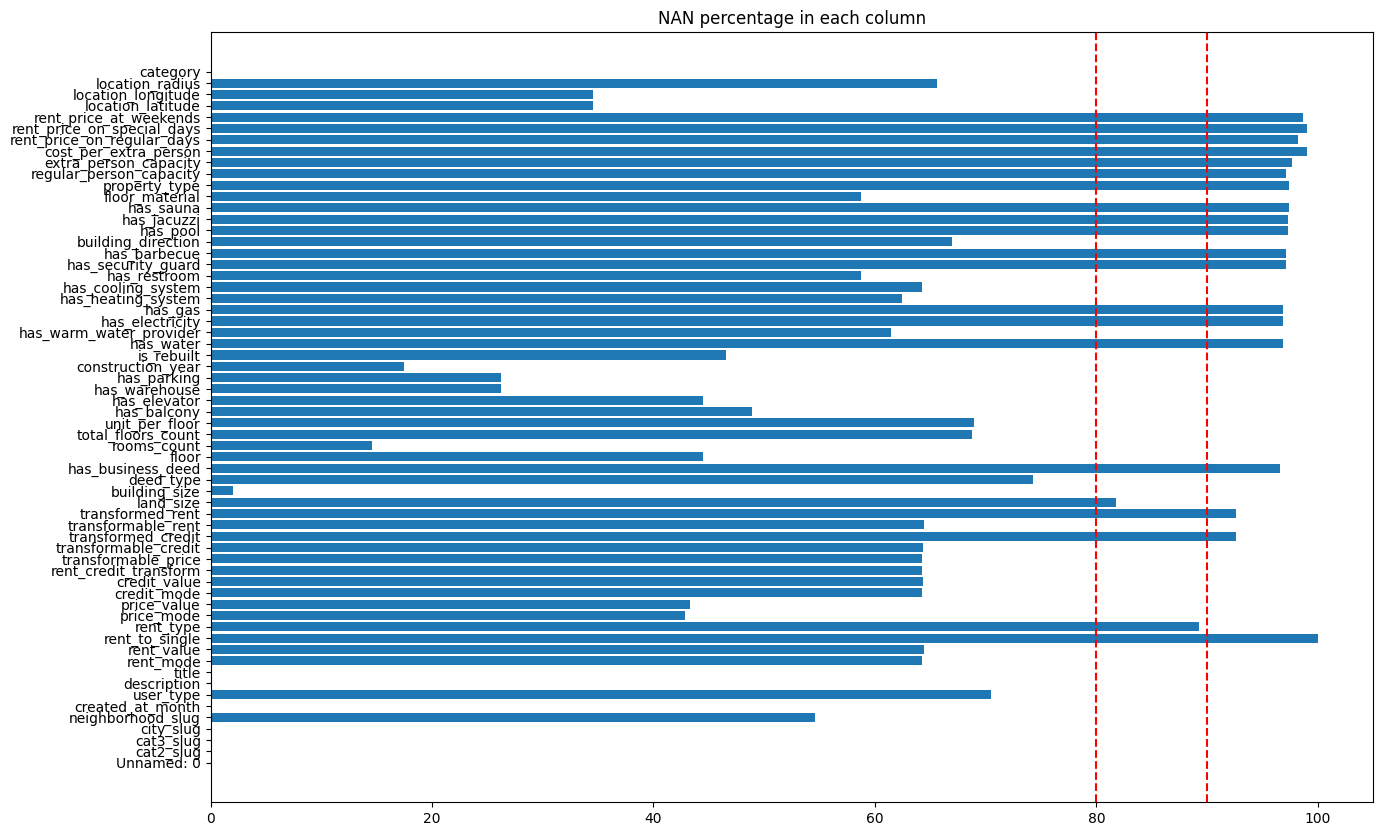

In [144]:
perc = df.isna().sum()*100/len(df)

gs = GridSpec(1, 1)
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(gs[0, 0])
ax.barh(df.columns, perc.values)
plt.axvline(x = 80, color = 'r', ls='--')
plt.axvline(x = 90, color = 'r', ls='--')
plt.title('NAN percentage in each column')
plt.show()

<Axes: >

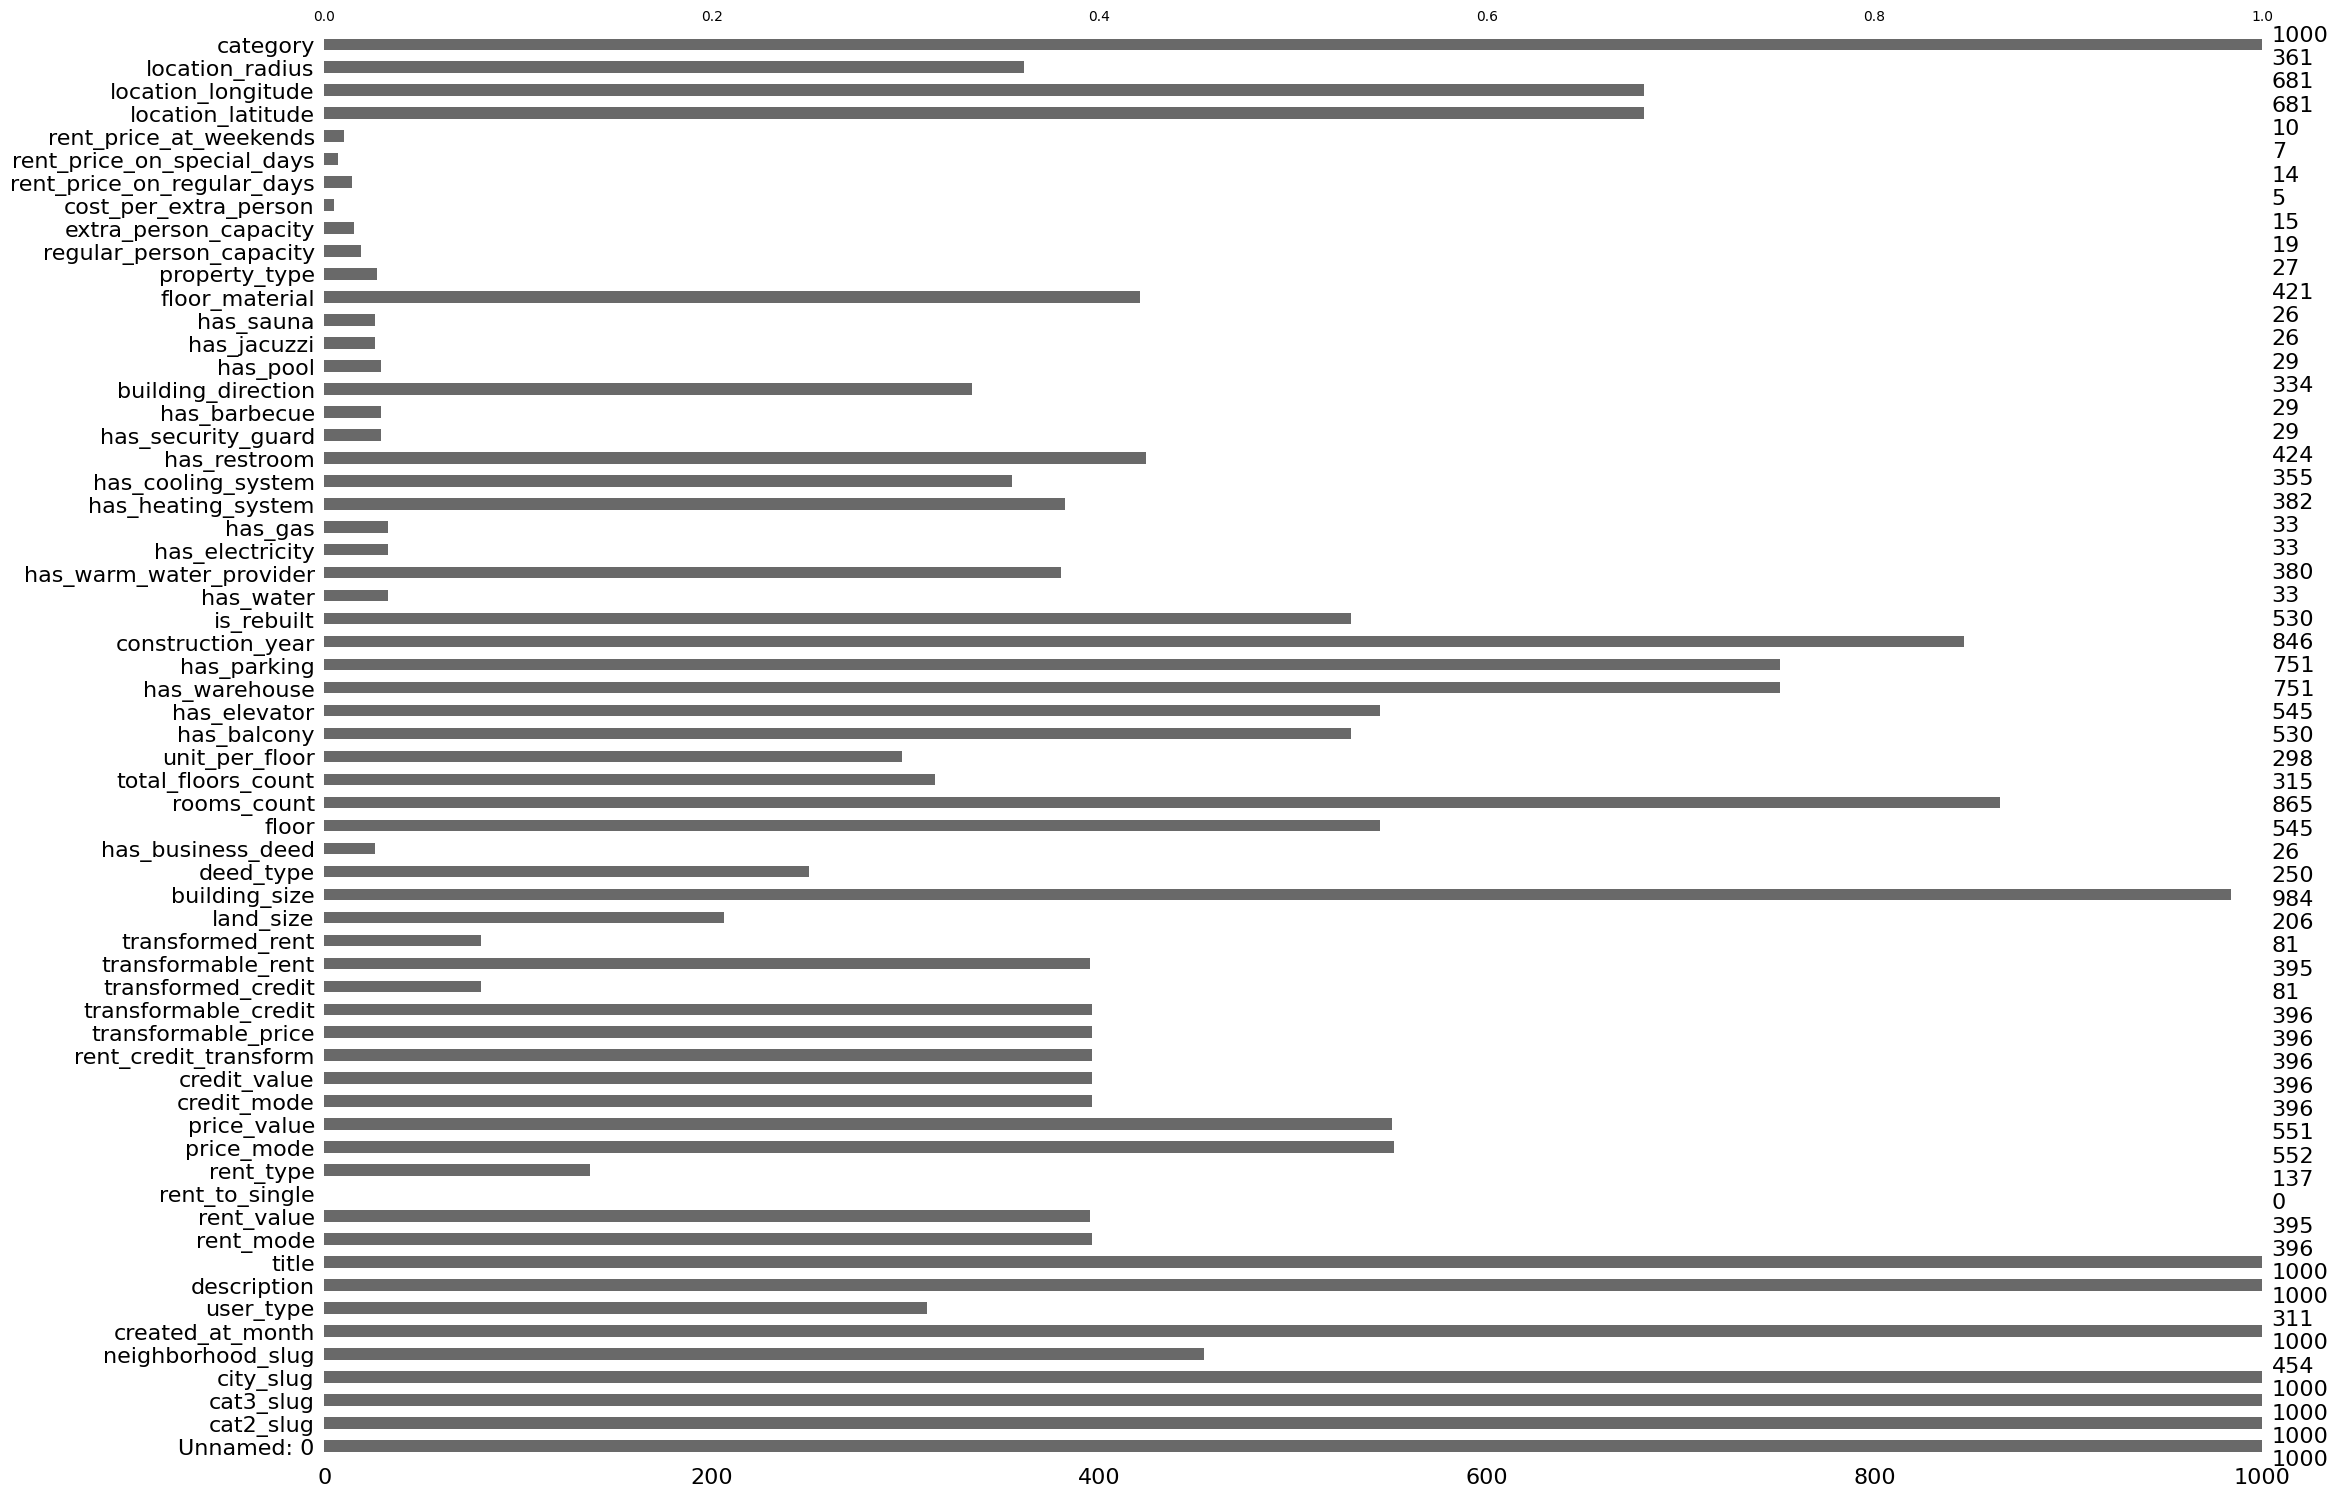

In [145]:
msno.bar(df.sample(1000))

<Axes: >

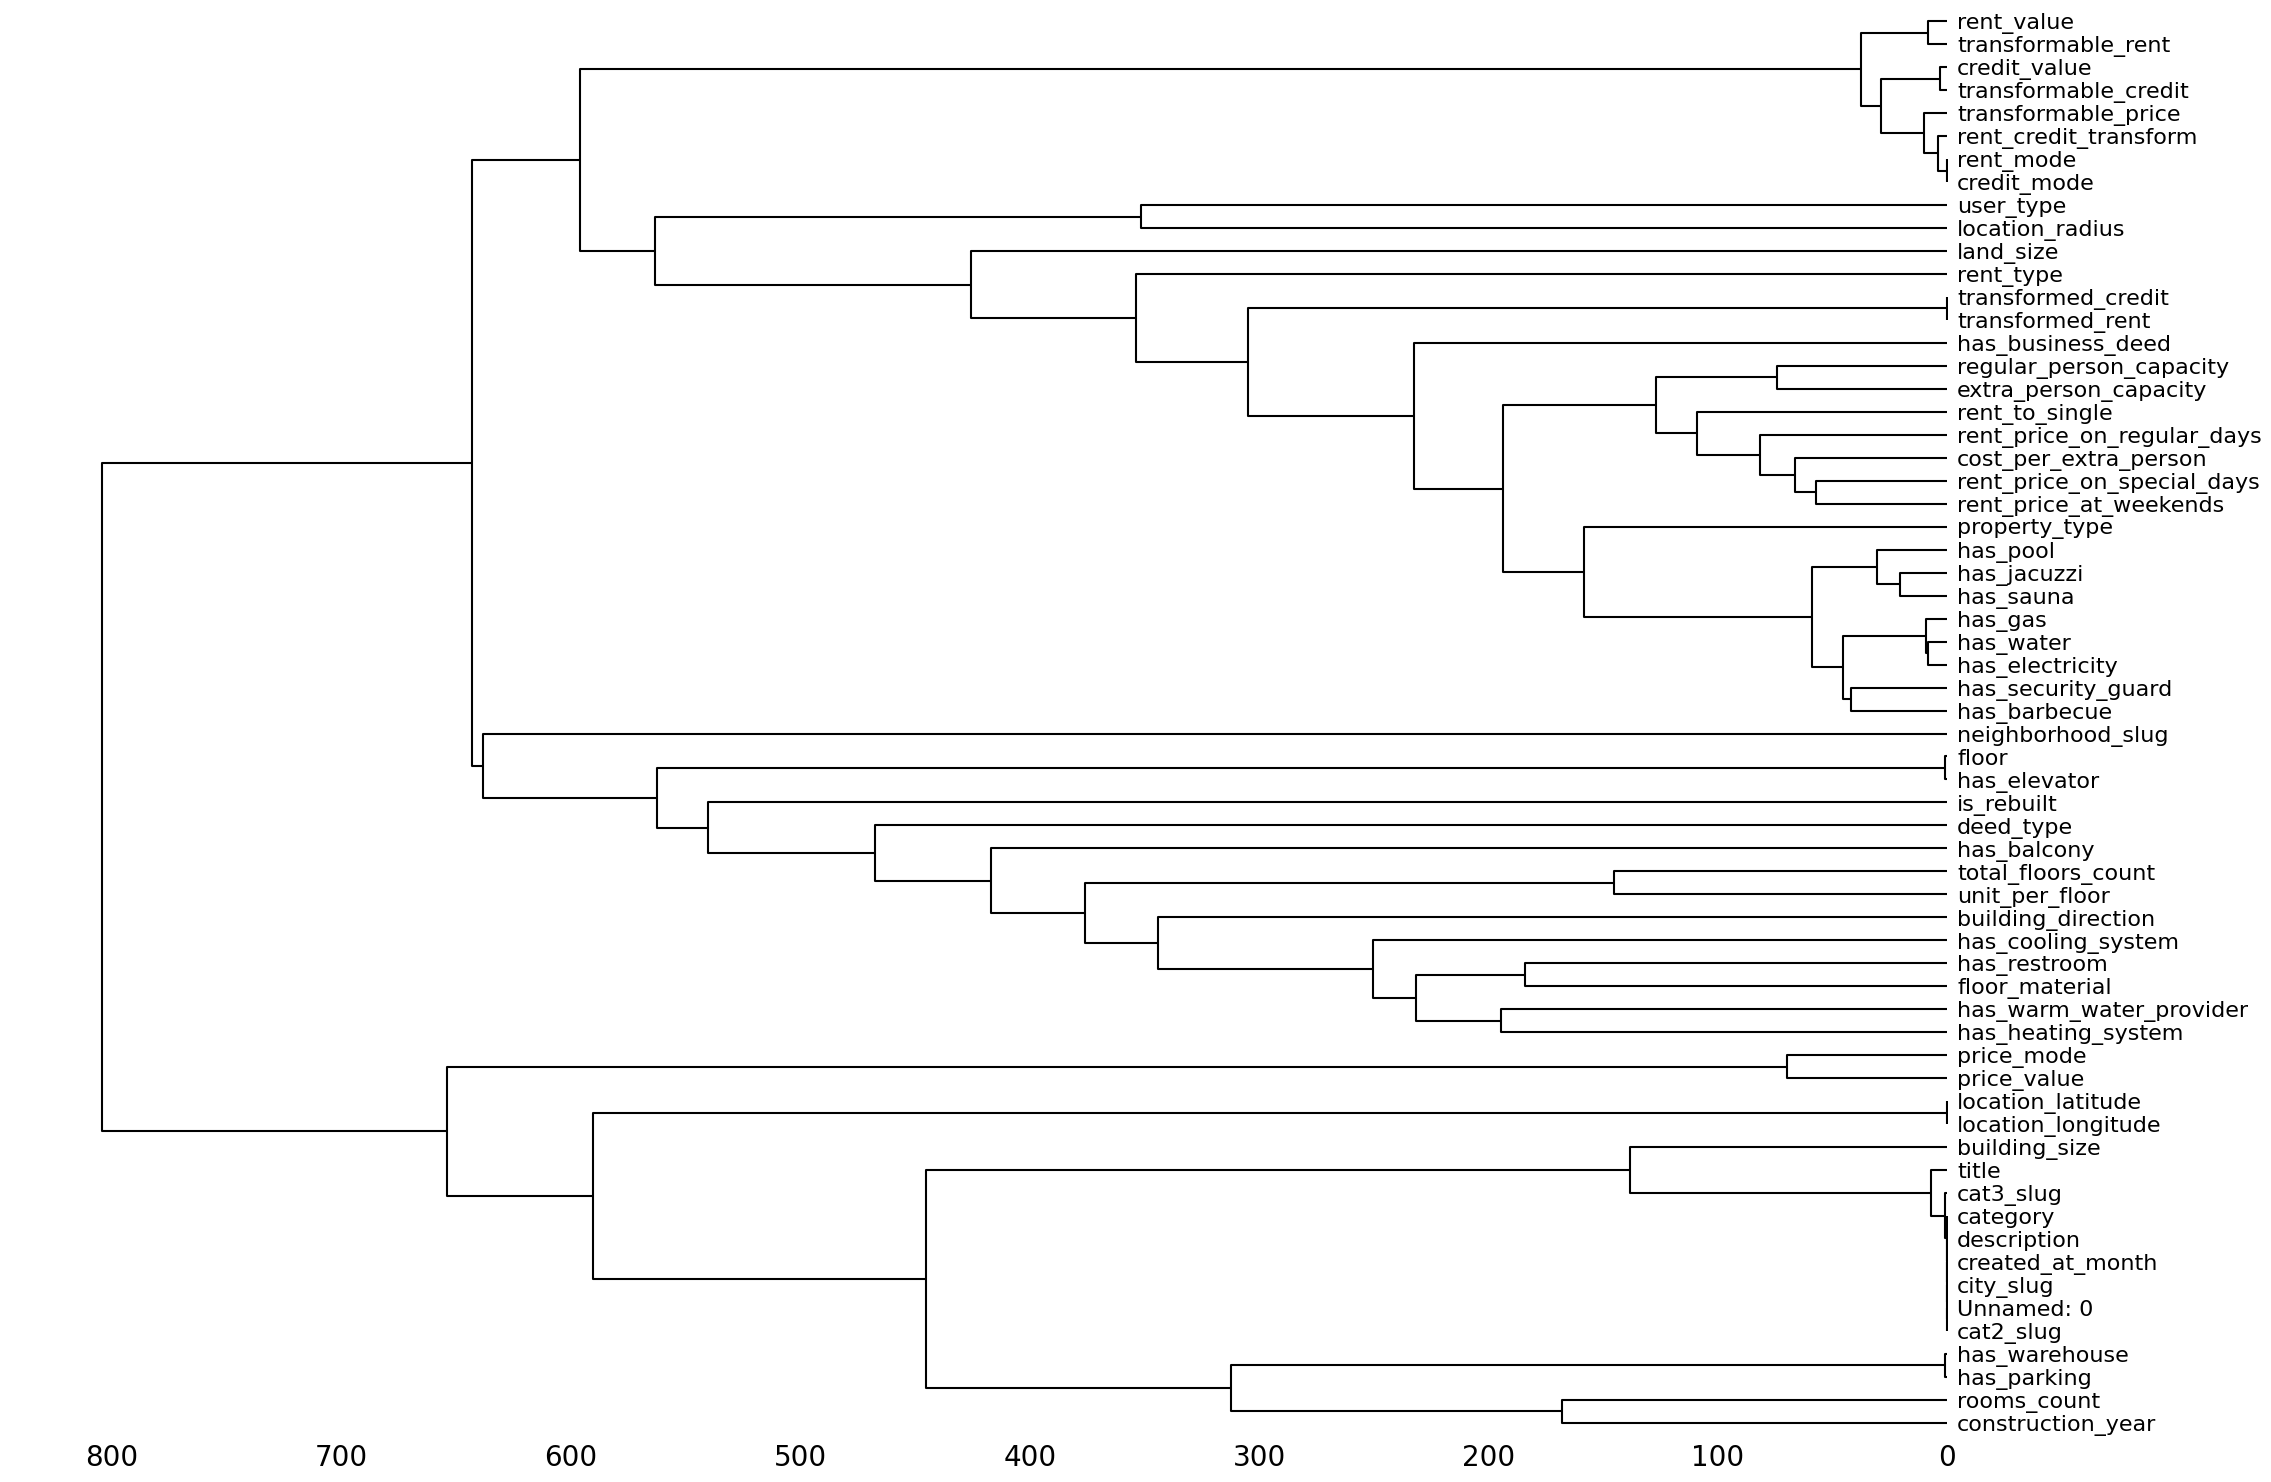

In [146]:
msno.dendrogram(df)

Some of features are unnecessary(have a lot of nan or has no info for predict price). So we can drop them!

In [147]:
df.columns

Index(['Unnamed: 0', 'cat2_slug', 'cat3_slug', 'city_slug',
       'neighborhood_slug', 'created_at_month', 'user_type', 'description',
       'title', 'rent_mode', 'rent_value', 'rent_to_single', 'rent_type',
       'price_mode', 'price_value', 'credit_mode', 'credit_value',
       'rent_credit_transform', 'transformable_price', 'transformable_credit',
       'transformed_credit', 'transformable_rent', 'transformed_rent',
       'land_size', 'building_size', 'deed_type', 'has_business_deed', 'floor',
       'rooms_count', 'total_floors_count', 'unit_per_floor', 'has_balcony',
       'has_elevator', 'has_warehouse', 'has_parking', 'construction_year',
       'is_rebuilt', 'has_water', 'has_warm_water_provider', 'has_electricity',
       'has_gas', 'has_heating_system', 'has_cooling_system', 'has_restroom',
       'has_security_guard', 'has_barbecue', 'building_direction', 'has_pool',
       'has_jacuzzi', 'has_sauna', 'floor_material', 'property_type',
       'regular_person_capacity',

In [148]:
df[['title', 'rent_mode', 'rent_value', 'rent_to_single', 'rent_type',
       'price_mode', 'price_value', 'credit_mode', 'credit_value',
       'rent_credit_transform', 'transformable_price', 'transformable_credit',
       'transformed_credit', 'transformable_rent', 'transformed_rent',]].head()

,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit,transformable_rent,transformed_rent
0,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,NaN,مقطوع,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,NaN,NaN,NaN,NaN,مقطوع,750000000.0,False,False,750000000.0,NaN,26000000.0,NaN
3,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,NaN,NaN,NaN,NaN,مقطوع,950000000.0,False,False,950000000.0,NaN,95000000.0,NaN
4,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,NaN,مقطوع,5.750000e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


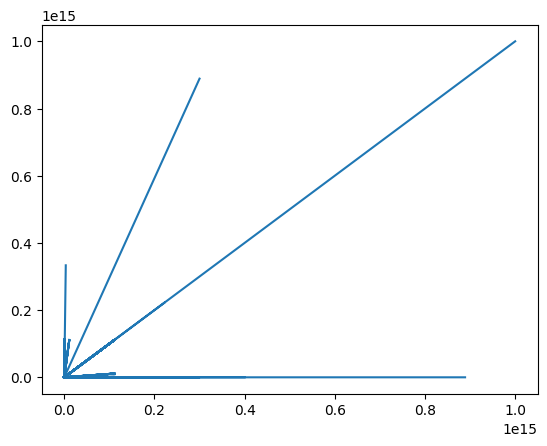

In [149]:
plt.plot(df['transformable_credit'], df['transformable_rent'])

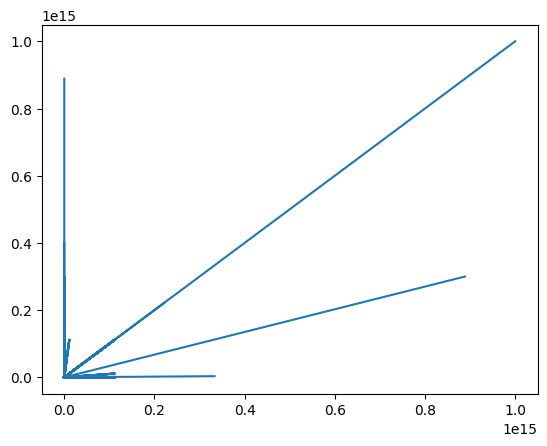

In [150]:
plt.plot(df['rent_value'], df['credit_value'])

In [151]:
df.cat2_slug.value_counts()

cat2_slug
residential-sell        535023
residential-rent        270052
commercial-rent          74566
commercial-sell          36906
temporary-rent           27752
real-estate-services     18978
Name: count, dtype: int64

In [152]:
df.cat3_slug.value_counts()

cat3_slug
apartment-sell                        299928
apartment-rent                        208957
plot-old                              120619
house-villa-sell                      114476
house-villa-rent                       61095
shop-rent                              44563
office-rent                            21277
shop-sell                              20920
presell                                15443
suite-apartment                        15407
villa                                  11821
industry-agriculture-business-sell     10874
industry-agriculture-business-rent      8725
office-sell                             5112
partnership                             3535
workspace                                524
Name: count, dtype: int64

In [153]:
df.property_type.value_counts()

property_type
jungle             15638
beach               3555
other               3307
jungle-mountain     2063
mountain             146
Name: count, dtype: int64

In [154]:
df1 = df.drop(['Unnamed: 0', 'cat2_slug', 'rent_to_single', 'rent_price_on_regular_days',
              'rent_price_on_special_days', 'rent_price_at_weekends', 'cost_per_extra_person',
              'extra_person_capacity', 'regular_person_capacity', 'title', 'description',
              'has_pool', 'has_jacuzzi', 'has_sauna', 'has_security_guard', 'has_barbecue',
              'has_water', 'has_electricity', 'has_gas', 'transformed_credit', 'transformable_rent','transformed_rent',
              'rent_credit_transform', 'has_business_deed', 'property_type', 'user_type'], axis=1)

In [155]:
df1.columns

Index(['cat3_slug', 'city_slug', 'neighborhood_slug', 'created_at_month',
       'rent_mode', 'rent_value', 'rent_type', 'price_mode', 'price_value',
       'credit_mode', 'credit_value', 'transformable_price',
       'transformable_credit', 'land_size', 'building_size', 'deed_type',
       'floor', 'rooms_count', 'total_floors_count', 'unit_per_floor',
       'has_balcony', 'has_elevator', 'has_warehouse', 'has_parking',
       'construction_year', 'is_rebuilt', 'has_warm_water_provider',
       'has_heating_system', 'has_cooling_system', 'has_restroom',
       'building_direction', 'floor_material', 'location_latitude',
       'location_longitude', 'location_radius', 'category'],
      dtype='object')

In [156]:
df1['rent_type'].value_counts()

rent_type
rent_credit    103048
full_credit       144
Name: count, dtype: int64

In [157]:
df1['rent_mode'].value_counts()

rent_mode
مقطوع     284690
مجانی      58177
توافقی      1625
Name: count, dtype: int64

In [158]:
df1[df1['credit_mode']=='مقطوع'][['transformable_credit', 'price_value']]

,transformable_credit,price_value
2,7.500000e+08,NaN
3,9.500000e+08,NaN
5,2.500000e+08,NaN
6,1.500000e+08,NaN
11,1.200000e+09,NaN
...,...,...
963262,2.200000e+08,NaN
963264,3.000000e+07,NaN
963270,1.500000e+08,NaN
963273,1.000000e+09,NaN


In [159]:
df1[df1['rent_mode']=='مجانی']['transformable_credit']

11        1.200000e+09
38        2.500000e+08
48        1.500000e+09
65        2.500000e+09
92        1.200000e+09
              ...     
963228    5.000000e+08
963236    3.600000e+08
963240    3.100000e+08
963246    4.600000e+08
963276    3.500000e+08
Name: transformable_credit, Length: 58177, dtype: float64

In [160]:
df1['has_balcony'].value_counts()

has_balcony
true        382337
false        84877
True         20194
False         4321
unselect       207
Name: count, dtype: int64

In [161]:
df1[['rent_mode', 'rent_type', 'price_mode', 'rent_value', 'credit_value',
       'price_value', 'credit_mode', 'transformable_price', 'transformable_credit']]

,rent_mode,rent_type,price_mode,rent_value,credit_value,price_value,credit_mode,transformable_price,transformable_credit
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,مقطوع,NaN,NaN,8.500000e+09,NaN,NaN,NaN
2,مقطوع,NaN,NaN,26000000.0,7.500000e+08,NaN,مقطوع,False,7.500000e+08
3,مقطوع,NaN,NaN,95000000.0,9.500000e+08,NaN,مقطوع,False,9.500000e+08
4,NaN,NaN,مقطوع,NaN,NaN,5.750000e+09,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
963272,NaN,NaN,مقطوع,NaN,NaN,7.470000e+09,NaN,NaN,NaN
963273,مقطوع,rent_credit,NaN,45000000.0,1.000000e+09,NaN,مقطوع,True,1.000000e+09
963274,NaN,NaN,مقطوع,NaN,NaN,3.200000e+09,NaN,NaN,NaN
963275,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## create full_price column as target 

In [162]:
df1.construction_year.value_counts()

construction_year
۱۴۰۳           113120
۱۳۹۰            57381
۱۴۰۲            56835
۱۴۰۰            52210
۱۳۹۵            51540
۱۳۹۸            37329
۱۳۹۷            35540
۱۳۹۶            34694
۱۴۰۱            34530
۱۳۸۵            33335
۱۳۹۹            28890
۱۳۹۳            28387
۱۳۹۴            25438
۱۳۹۲            25334
۱۳۸۸            23804
۱۳۸۰            22809
قبل از ۱۳۷۰     19688
۱۳۸۹            16391
۱۳۹۱            15870
۱۳۸۷            13867
۱۳۸۶            13181
۱۳۸۳             9746
۱۳۸۴             8367
۱۳۷۵             7009
۱۳۸۲             6834
۱۳۷۱             5316
۱۳۸۱             3523
۱۳۷۸             2952
۱۳۷۹             2349
۱۳۷۷             2037
۱۳۷۲             1837
۱۳۷۳             1769
۱۳۷۶             1544
۱۳۷۴             1245
Name: count, dtype: int64

In [163]:
df1.loc[df1.construction_year=='قبل از ۱۳۷۰', 'construction_year'] = 1369
df1.construction_year = df1.construction_year.astype('float')


In [164]:
df1['full_price'] = df1['price_value']

df1['full_credit'] = df1['credit_value'] + (df1['rent_value']/3)*100
df1['full_credit']

0                  NaN
1                  NaN
2         1.616667e+09
3         4.116667e+09
4                  NaN
              ...     
963272             NaN
963273    2.500000e+09
963274             NaN
963275             NaN
963276    3.500000e+08
Name: full_credit, Length: 963277, dtype: float64

In [165]:
this_year = max(df1.construction_year.value_counts().index)

def find_full_price(x):
    if x['full_price'] is not None:
        return x['full_price']
    if x['construction_year'] is None:
        return x['full_credit']*5
    elif this_year - x['construction_year'] < 5:
        return x['full_credit']*4
    elif this_year - x['construction_year'] < 10:
        return x['full_credit']*5
    else:
        return x['full_credit']*6

In [166]:
df1['full_price'] = df1.apply(find_full_price, axis=1)

In [167]:
df1['full_price'].isna().sum()

np.int64(417303)

In [168]:
df2 = df1.dropna(subset=['full_price']).reset_index().drop(['index', 'rent_mode', 'rent_type', 'price_mode', 'rent_value', 'credit_value',
       'price_value', 'credit_mode', 'transformable_price', 'transformable_credit', 'full_credit'], axis=1)

In [169]:
df2.full_price = df2.full_price/1000000

In [170]:
(df2.sort_values(by='full_price')['full_price']<100).sum()

np.int64(15637)

{'whiskers': [<matplotlib.lines.Line2D at 0x24309ac5410>,
 'caps': [<matplotlib.lines.Line2D at 0x24309ac6550>,
 'boxes': [<matplotlib.lines.Line2D at 0x24309a5b0d0>],
 'medians': [<matplotlib.lines.Line2D at 0x24309ac7810>],
 'fliers': [<matplotlib.lines.Line2D at 0x24309ab8050>],
 'means': []}

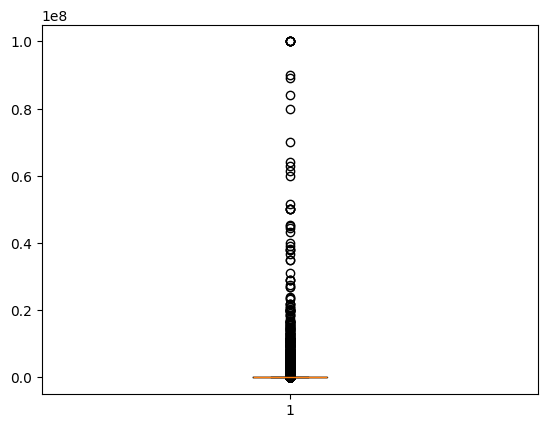

In [171]:
plt.boxplot(df2.full_price)

<Axes: >

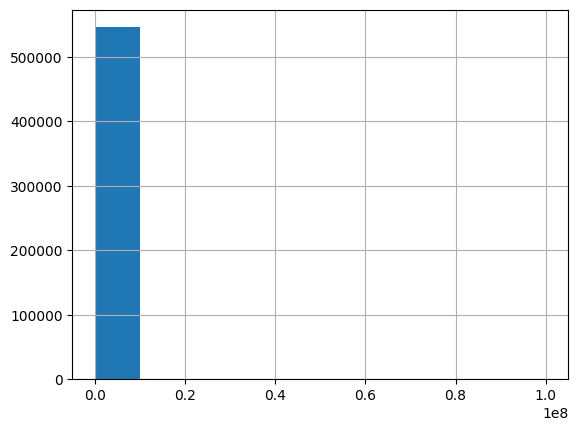

In [172]:
df2.full_price.hist()

In [173]:
df2[['full_price']].describe()

,full_price
count,5.459740e+05
mean,1.757708e+04
std,5.966470e+05
min,0.000000e+00
25%,1.450000e+03
50%,2.900000e+03
75%,6.000000e+03
max,1.000000e+08


In [174]:
len(df2[(df2.full_price<500)|(df2.full_price>1e6)])/len(df)*100

4.302085485275783

In [175]:
df2 = df2.drop(df2[(df2.full_price<500)|(df2.full_price>1e6)].index)

{'whiskers': [<matplotlib.lines.Line2D at 0x243ee43aed0>,
 'caps': [<matplotlib.lines.Line2D at 0x243ee424190>,
 'boxes': [<matplotlib.lines.Line2D at 0x243ee43a750>],
 'medians': [<matplotlib.lines.Line2D at 0x243ee4256d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x243ee4261d0>],
 'means': []}

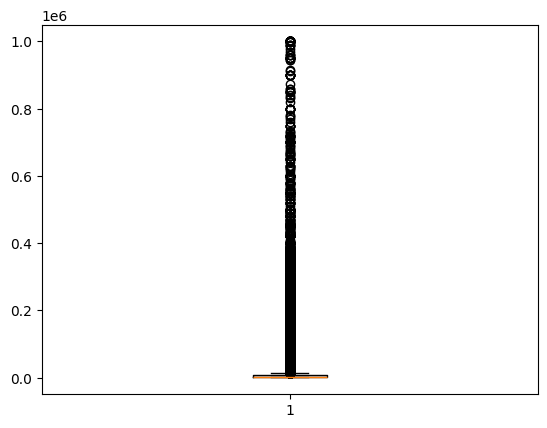

In [176]:
plt.boxplot(df2.full_price)

<Axes: >

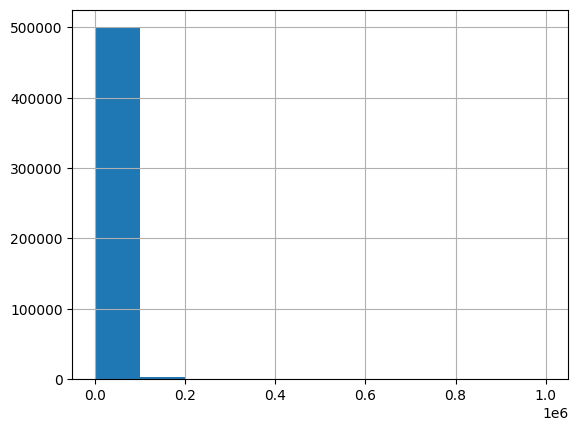

In [177]:
df2.full_price.hist()

In [178]:
def replace_outliers(df, c_name):
    c = df[c_name]
    c = df[c_name].astype(float)
    q1 = c.quantile(0.25)
    q3 = c.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5*iqr
    lower = q1 - 1.5*iqr
    
    c = np.where(c>upper, upper, c)
    c = np.where(c<lower, lower, c)
    df.loc[:, c_name] = c
    return df

In [179]:
df2 = replace_outliers(df2, 'full_price')

{'whiskers': [<matplotlib.lines.Line2D at 0x243472dad90>,
 'caps': [<matplotlib.lines.Line2D at 0x243472dbe50>,
 'boxes': [<matplotlib.lines.Line2D at 0x243472da450>],
 'medians': [<matplotlib.lines.Line2D at 0x243472cd510>],
 'fliers': [<matplotlib.lines.Line2D at 0x243472cdfd0>],
 'means': []}

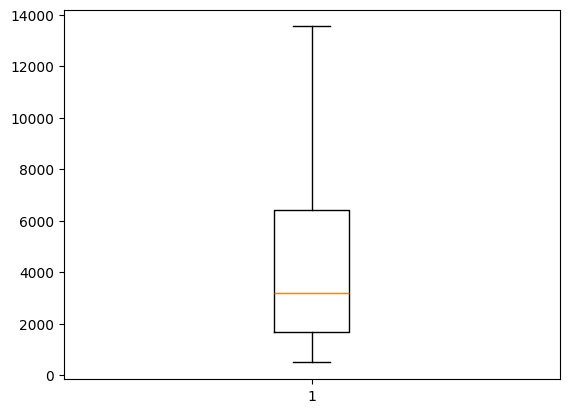

In [180]:
plt.boxplot(df2.full_price)

<Axes: >

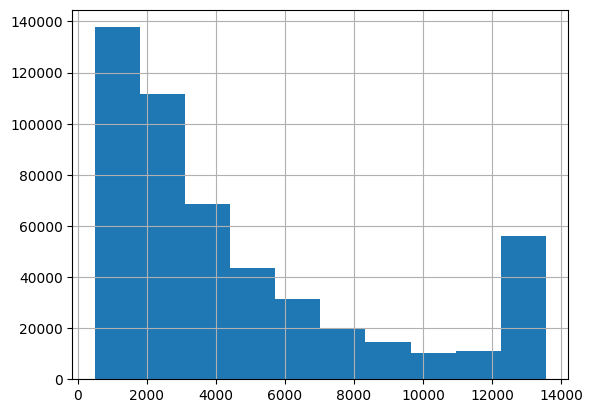

In [181]:
df2.full_price.hist()

In [182]:
df2.sort_values(by='full_price')

,cat3_slug,city_slug,neighborhood_slug,created_at_month,land_size,building_size,deed_type,floor,rooms_count,total_floors_count,...,has_heating_system,has_cooling_system,has_restroom,building_direction,floor_material,location_latitude,location_longitude,location_radius,category,full_price
226750,industry-agriculture-business-sell,khorramdarreh,NaN,2024-06-01 00:00:00,NaN,1000.0,NaN,NaN,بدون اتاق,NaN,...,NaN,NaN,NaN,NaN,NaN,36.184124,49.137890,NaN,شهر کوچک,500.0
231647,plot-old,khorramshahr,NaN,2024-11-01 00:00:00,NaN,222.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,30.423847,48.200531,NaN,شهر کوچک,500.0
3037,industry-agriculture-business-sell,torbat-jam,NaN,2024-08-01 00:00:00,NaN,385.0,NaN,NaN,یک,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,شهر کوچک,500.0
76213,plot-old,bushehr,NaN,2024-07-01 00:00:00,NaN,400.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,شهر کوچک,500.0
63930,house-villa-sell,chamestan,NaN,2023-11-01 00:00:00,225.0,100.0,single_page,NaN,دو,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0,شهر کوچک,500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301005,apartment-sell,tehran,aghdasieh,2024-10-01 00:00:00,NaN,180.0,other,1,سه,6,...,duct_split,duct_split,seat,south,stone,35.808346,51.479855,NaN,کلان‌شهر,13550.0
152729,apartment-sell,tehran,elahiyeh,2024-06-01 00:00:00,NaN,278.0,single_page,4,سه,10,...,fan_coil,fan_coil,seat,north,stone,NaN,NaN,NaN,کلان‌شهر,13550.0
545947,apartment-sell,shiraz,moaliabad,2024-10-01 00:00:00,NaN,260.0,NaN,4.0,سه,NaN,...,NaN,NaN,NaN,NaN,NaN,29.679001,52.461166,NaN,کلان‌شهر,13550.0
301039,plot-old,fasham-city,NaN,2024-10-01 00:00:00,NaN,402.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,35.952866,51.560883,NaN,شهر کوچک,13550.0


In [183]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504533 entries, 0 to 545973
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat3_slug                504533 non-null  object 
 1   city_slug                504533 non-null  object 
 2   neighborhood_slug        223844 non-null  object 
 3   created_at_month         504533 non-null  object 
 4   land_size                105824 non-null  float64
 5   building_size            503362 non-null  float64
 6   deed_type                239227 non-null  object 
 7   floor                    294852 non-null  object 
 8   rooms_count              423052 non-null  object 
 9   total_floors_count       180716 non-null  object 
 10  unit_per_floor           178569 non-null  object 
 11  has_balcony              293524 non-null  object 
 12  has_elevator             294852 non-null  object 
 13  has_warehouse            400680 non-null  object 
 14  has_parki

In [184]:
df2['created_at_month'] = pd.to_datetime(df2['created_at_month'])

In [185]:
df2['created_at_month'].apply(lambda x: x.year).value_counts()

created_at_month
2024    502585
2023      1023
2025       897
2022        26
2021         2
Name: count, dtype: int64

In [186]:
df2['year'] = df2['created_at_month'].apply(lambda x: x.year)
df2 = df2[df2.year==2024]
df2 = df2.drop(['created_at_month', 'year'], axis=1)

In [187]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 502585 entries, 0 to 545973
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat3_slug                502585 non-null  object 
 1   city_slug                502585 non-null  object 
 2   neighborhood_slug        223205 non-null  object 
 3   land_size                105265 non-null  float64
 4   building_size            501415 non-null  float64
 5   deed_type                238138 non-null  object 
 6   floor                    293760 non-null  object 
 7   rooms_count              421343 non-null  object 
 8   total_floors_count       180031 non-null  object 
 9   unit_per_floor           177889 non-null  object 
 10  has_balcony              292260 non-null  object 
 11  has_elevator             293760 non-null  object 
 12  has_warehouse            399029 non-null  object 
 13  has_parking              399029 non-null  object 
 14  construct

## split data into train, validation, and test

In [188]:
X = df2.drop(['full_price'], axis=1)
y = df2['full_price']

In [189]:
X_train, X_test1, y_train, y_test1 = train_test_split(
    X, y, test_size=0.4, random_state=42)

In [190]:
X_valid, X_test, y_valid, y_test = train_test_split(
    X_test1, y_test1, test_size=0.4, random_state=42)

In [191]:
train_data = pd.concat([X_train, pd.DataFrame(y_train)], axis=1).reset_index().drop(columns=['index'])

In [192]:
X_valid = X_valid.reset_index().drop(columns=['index'])
X_test = X_test.reset_index().drop(columns=['index'])

In [193]:
train_data.groupby(['city_slug', 'neighborhood_slug'])['full_price'].mean().to_csv('price_group.csv')

## Handling missing values

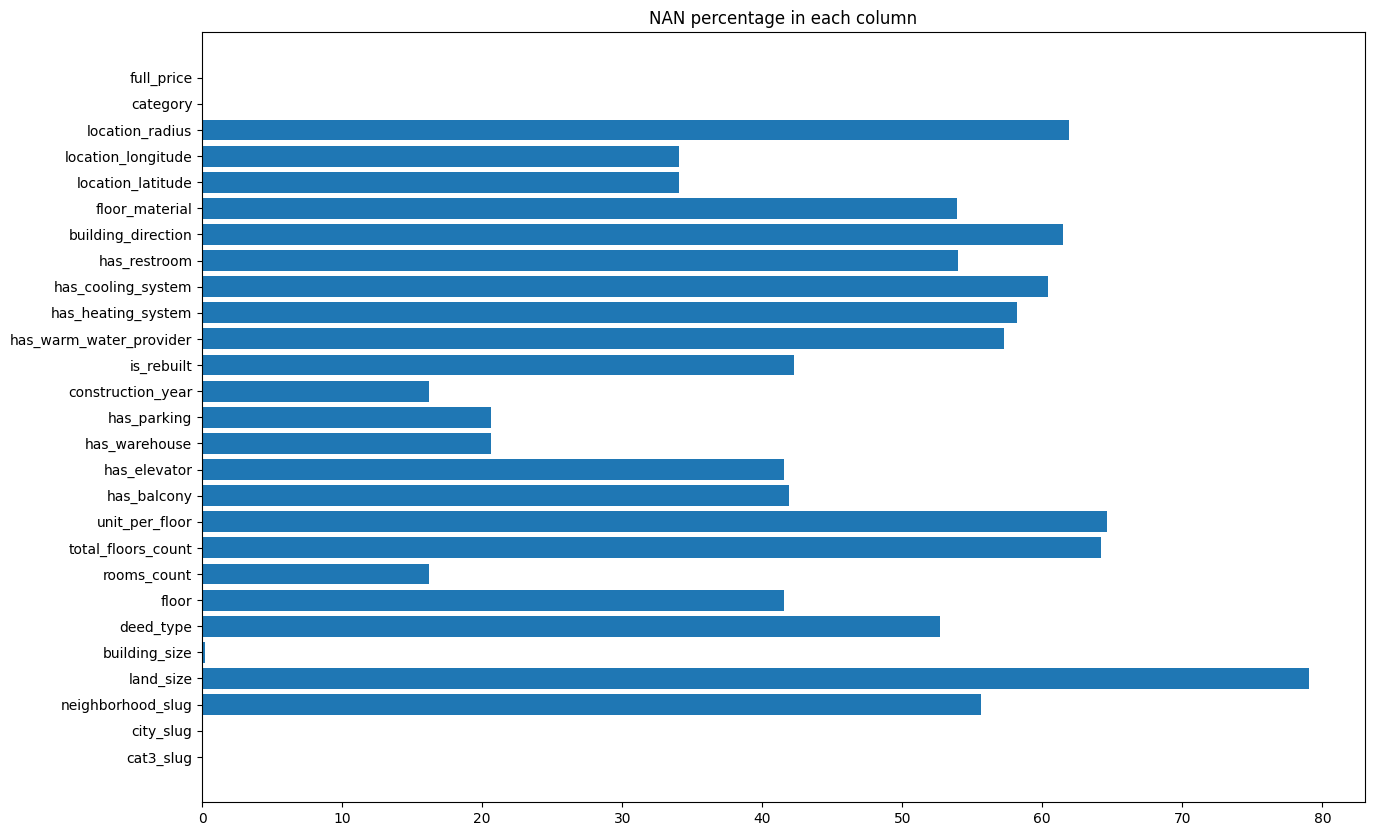

In [194]:
perc = train_data.isna().sum()*100/len(train_data)

gs = GridSpec(1, 1)
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(gs[0, 0])
ax.barh(train_data.columns, perc.values)
plt.title('NAN percentage in each column')
plt.show()

### neighborhood_slug

In [195]:
train_data.city_slug.value_counts()

city_slug
tehran        57813
mashhad       20042
karaj         16533
isfahan       11682
shiraz        10379
              ...  
kiasar           32
hendijan         23
shal             22
lavandevil       21
hormuz           13
Name: count, Length: 240, dtype: int64

In [196]:
train_data.groupby(['city_slug'])['neighborhood_slug'].apply(pd.Series.mode)

city_slug       
ahvaz          0              kianpars
bandar-anzali  0             jahangani
isfahan        0    baharestan-esfahan
karaj          0       andishehnewcity
lahijan        0               ahandan
               1                   lil
mashhad        0          elahiyehblvd
qom            0         pardisan-ghom
rasht          0               golsaar
shiraz         0              mianrood
talesh         0              hashtpar
tehran         0                poonak
Name: neighborhood_slug, dtype: object

In [197]:
train_data['neighborhood_slug'].value_counts()

neighborhood_slug
elahiyehblvd           2669
poonak                 1656
ghasemabad             1519
bolvartoos             1387
jeyhoun                1324
                       ... 
kuy-qlam-niya             1
kuy-mehr-rasht            1
qiyam                     1
torbeh-gudeh              1
qasr-e-firoozeh-yek       1
Name: count, Length: 1153, dtype: int64

As you see, most of the cities don't have neighborhood_slug. We can concat this column with city and create a new column.

In [198]:
train_data['neighborhood_slug'] = train_data['neighborhood_slug'].fillna('')
X_valid['neighborhood_slug'] = X_valid['neighborhood_slug'].fillna('')
X_test['neighborhood_slug'] = X_test['neighborhood_slug'].fillna('')

In [199]:
train_data['city_neighborhood'] = train_data['city_slug'] + train_data['neighborhood_slug']
X_valid['city_neighborhood'] = X_valid['city_slug'] + X_valid['neighborhood_slug']
X_test['city_neighborhood'] = X_test['city_slug'] + X_test['neighborhood_slug']

In [200]:
train_data['city_neighborhood'].value_counts()

city_neighborhood
tabriz                          9523
andisheh-new-town               9179
kermanshah                      5024
pardis-city                     4693
urmia                           4190
                                ... 
bandar-anzaliansar-alhosein        1
bandar-anzalishanghai-pardeh       1
bandar-anzalikhosh-pik             1
lahijanenqelab-lahijan             1
tehranqasr-e-firoozeh-yek          1
Name: count, Length: 1385, dtype: int64

In [201]:
train_data = train_data.drop(['city_slug', 'neighborhood_slug'], axis=1)
X_valid = X_valid.drop(['city_slug', 'neighborhood_slug'], axis=1)
X_test = X_test.drop(['city_slug', 'neighborhood_slug'], axis=1)

### building_size

In [202]:
sum(train_data['building_size'].isna())

670

In [203]:
train_data[train_data['building_size'].isna()]['city_neighborhood'].unique()

array(['andisheh-new-town', 'tehrandehkade-olympic', 'ardabil',
       'rashtgaaz', 'tehranestakhr', 'chahar-dangeh', 'tabriz', 'gorgan',
       'ahvazkianshahr', 'tehranchitgar-lake', 'isfahan24-metri',
       'tehranshahrak-e-ferdows', 'karajbaghestan', 'shiraztachara',
       'isfahanshahishabad', 'tehrannorth-sohrevardi', 'kermanshah',
       'qomensejam', 'tehranshahrak-shahid-bagheri',
       'tehrankooy-e-ferdos', 'sanandaj', 'kerman', 'bandar-abbas',
       'rashthamidiyan', 'dorud', 'rashtpol-taleshan', 'chalus',
       'shirazkolbeh', 'isfahangaz', 'zanjan', 'shahriar-city',
       'salman-shahr', 'semnan', 'tehranjey', 'shirazfarhangian-shiraz',
       'kish', 'tehranberyanak', 'shirazbesat', 'mashhadelahiyehblvd',
       'mohammad-shahr', 'pardis-city', 'mashhadvakilabad', 'zahedan',
       'khoy', 'qazvin', 'mashhadghasemabad', 'mashhadkuy-e-kowsar',
       'mashhadkuy-e-amiralmomenin', 'yazd', 'dezful', 'mahmudabad',
       'khorramabad', 'shirazfarhangshahr', 'parand-cit

In [204]:
group_temp = train_data.groupby(['city_neighborhood'])['building_size'].median().reset_index().rename(columns={'building_size': 'med'})

train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['building_size'] = train_data['building_size'].fillna(train_temp['med'])

In [205]:
sum(X_valid['building_size'].isna()), sum(X_test['building_size'].isna())

(297, 203)

In [206]:
valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['building_size'] = X_valid['building_size'].fillna(valid_temp['med'])

In [207]:
test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['building_size'] = X_test['building_size'].fillna(test_temp['med'])

In [208]:
sum(X_valid['building_size'].isna()), sum(X_test['building_size'].isna())

(0, 0)

### land size

In [209]:
group_temp = train_data.groupby(['building_size'])['land_size'].median().ffill().reset_index().rename(columns={'land_size': 'med'})

train_temp = train_data[['building_size']].merge(group_temp, on=['building_size'], how='left')
train_data['land_size'] = train_data['land_size'].fillna(train_temp['med'])

In [210]:
sum(X_valid['land_size'].isna()), sum(X_test['land_size'].isna())

(95409, 63499)

In [211]:
valid_temp = X_valid[['building_size']].merge(group_temp, on=['building_size'], how='left')
X_valid['land_size'] = X_valid['land_size'].fillna(valid_temp['med'])

test_temp = X_test[['building_size']].merge(group_temp, on=['building_size'], how='left')
X_test['land_size'] = X_test['land_size'].fillna(test_temp['med'])

In [212]:
sum(X_valid['land_size'].isna()), sum(X_test['land_size'].isna())

(345, 201)

In [213]:
X_valid['land_size'] = X_valid['land_size'].fillna(X_valid['building_size'])

X_test['land_size'] = X_test['land_size'].fillna(X_test['building_size'])

In [214]:
sum(X_valid['land_size'].isna()), sum(X_test['land_size'].isna())

(0, 0)

### deed_type

In [215]:
train_data.deed_type.value_counts()

deed_type
single_page          110281
written_agreement     17485
other                 11279
multi_page             3378
unselect                294
Name: count, dtype: int64

In [216]:
train_data.loc[train_data['deed_type']=='unselect','deed_type'] = None
X_valid.loc[X_valid['deed_type']=='unselect','deed_type'] = None
X_test.loc[X_test['deed_type']=='unselect','deed_type'] = None

first we need to convert it to numerical

In [217]:
le = LabelEncoder()
train_data['deed_type'] = le.fit_transform(train_data['deed_type'])
X_valid['deed_type'] = le.transform(X_valid['deed_type'])
X_test['deed_type'] = le.transform(X_test['deed_type'])

In [218]:
imputer = KNNImputer(n_neighbors=3, weights='distance', metric='nan_euclidean', add_indicator=False)

In [219]:
train_data[['deed_type']] = imputer.fit_transform(train_data[['deed_type']])
X_valid[['deed_type']] = imputer.transform(X_valid[['deed_type']])
X_test[['deed_type']] = imputer.transform(X_test[['deed_type']])

### total_floors_count

In [220]:
train_data['total_floors_count'].value_counts()

total_floors_count
4           32817
5           30081
3           17596
6           11109
2            4965
7            3185
8            1620
14           1402
10            944
9             680
12            593
11            513
13            476
15            394
16            260
20            206
18            172
21            131
25            121
17            104
19             91
30             90
30+            81
24             65
22             48
29             46
unselect       32
26             25
4.0            22
5.0            19
3.0            16
23             12
27              9
6.0             7
28              6
7.0             2
2.0             2
10.0            2
20.0            1
21.0            1
25.0            1
13.0            1
Name: count, dtype: int64

In [221]:
train_data.loc[train_data['total_floors_count']=='30+','total_floors_count'] = '30'
X_valid.loc[X_valid['total_floors_count']=='30+','total_floors_count'] = '30'
X_test.loc[X_test['total_floors_count']=='30+','total_floors_count'] = '30'

In [222]:
train_data.loc[train_data['total_floors_count']=='unselect','total_floors_count'] = None
X_valid.loc[X_valid['total_floors_count']=='unselect','total_floors_count'] = None
X_test.loc[X_test['total_floors_count']=='unselect','total_floors_count'] = None

In [223]:
train_data['total_floors_count'] = train_data['total_floors_count'].astype('float')
X_valid['total_floors_count'] = X_valid['total_floors_count'].astype('float')
X_test['total_floors_count'] = X_test['total_floors_count'].astype('float')

In [224]:
train_data.groupby(['city_neighborhood'])['total_floors_count'].median().reset_index().isna().sum()

city_neighborhood       0
total_floors_count    125
dtype: int64

In [225]:
group_temp = train_data.groupby(['city_neighborhood'])['total_floors_count'].median().reset_index().ffill().rename(columns={'total_floors_count': 'med'})

train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['total_floors_count'] = train_data['total_floors_count'].fillna(train_temp['med'])

In [226]:
valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['total_floors_count'] = X_valid['total_floors_count'].fillna(valid_temp['med'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['total_floors_count'] = X_test['total_floors_count'].fillna(test_temp['med'])

In [227]:
sum(X_valid['total_floors_count'].isna()), sum(X_test['total_floors_count'].isna())

(9, 12)

In [228]:
med_total_foors = train_data['total_floors_count'].median()
X_valid['total_floors_count'] = X_valid['total_floors_count'].fillna(med_total_foors)
X_test['total_floors_count'] = X_test['total_floors_count'].fillna(med_total_foors)

In [229]:
train_data['total_floors_count'] = train_data['total_floors_count'].astype('int')
X_valid['total_floors_count'] = X_valid['total_floors_count'].astype('int')
X_test['total_floors_count'] = X_test['total_floors_count'].astype('int')

### floor

In [230]:
train_data['floor'].value_counts()

floor
2       42044
3       37380
1       36833
4       25245
5       13407
0        8378
6        4968
7        2005
8        1117
10        863
9         756
11        554
-1        512
12        472
14        315
13        300
30+       234
15        163
16        115
17        101
18         81
20         62
21         48
19         46
25         34
1.0        29
22         26
3.0        25
2.0        25
30         24
23         24
24         17
28         15
4.0        11
5.0         9
26          8
0.0         6
29          6
27          6
6.0         3
14.0        1
20.0        1
7.0         1
10.0        1
Name: count, dtype: int64

In [231]:
train_data.loc[train_data['floor']=='30+','floor'] = '30'
X_valid.loc[X_valid['floor']=='30+','floor'] = '30'
X_test.loc[X_test['floor']=='30+','floor'] = '30'

In [232]:
train_data['floor'] = train_data['floor'].astype('float')
X_valid['floor'] = X_valid['floor'].astype('float')
X_test['floor'] = X_test['floor'].astype('float')

In [233]:
train_data.groupby(['total_floors_count'])['floor'].median().reset_index().isna().sum()

total_floors_count    0
floor                 0
dtype: int64

In [234]:
group_temp = train_data.groupby(['total_floors_count'])['floor'].median().reset_index().rename(columns={'floor': 'med'})

train_temp = train_data[['total_floors_count']].merge(group_temp, on=['total_floors_count'], how='left')
train_data['floor'] = train_data['floor'].fillna(train_temp['med'])

In [235]:
valid_temp = X_valid[['total_floors_count']].merge(group_temp, on=['total_floors_count'], how='left')
X_valid['floor'] = X_valid['floor'].fillna(valid_temp['med'])

test_temp = X_test[['total_floors_count']].merge(group_temp, on=['total_floors_count'], how='left')
X_test['floor'] = X_test['floor'].fillna(test_temp['med'])

In [236]:
sum(X_valid['floor'].isna()), sum(X_test['floor'].isna())

(0, 0)

In [237]:
train_data['floor'] = train_data['floor'].astype('int')
X_valid['floor'] = X_valid['floor'].astype('int')
X_test['floor'] = X_test['floor'].astype('int')

### unit_per_floor

In [238]:
train_data['unit_per_floor'].value_counts()

unit_per_floor
2              43376
1              31184
4              14103
3              11910
5               1767
6               1753
8               1335
more_than_8      795
7                328
unselect          92
Name: count, dtype: int64

In [239]:
train_data.loc[train_data['unit_per_floor']=='more_than_8','unit_per_floor'] = '9'
X_valid.loc[X_valid['unit_per_floor']=='more_than_8','unit_per_floor'] = '9'
X_test.loc[X_test['unit_per_floor']=='more_than_8','unit_per_floor'] = '9'

In [240]:
train_data.loc[train_data['unit_per_floor']=='unselect','unit_per_floor'] = None
X_valid.loc[X_valid['unit_per_floor']=='unselect','unit_per_floor'] = None
X_test.loc[X_test['unit_per_floor']=='unselect','unit_per_floor'] = None

In [241]:
train_data['unit_per_floor'] = train_data['unit_per_floor'].astype('float')
X_valid['unit_per_floor'] = X_valid['unit_per_floor'].astype('float')
X_test['unit_per_floor'] = X_test['unit_per_floor'].astype('float')

In [242]:
group_temp = train_data.groupby(['total_floors_count'])['unit_per_floor'].median().reset_index().rename(columns={'unit_per_floor': 'med'})

train_temp = train_data[['total_floors_count']].merge(group_temp, on=['total_floors_count'], how='left')
train_data['unit_per_floor'] = train_data['unit_per_floor'].fillna(train_temp['med'])

In [243]:
valid_temp = X_valid[['total_floors_count']].merge(group_temp, on=['total_floors_count'], how='left')
X_valid['unit_per_floor'] = X_valid['unit_per_floor'].fillna(valid_temp['med'])

test_temp = X_test[['total_floors_count']].merge(group_temp, on=['total_floors_count'], how='left')
X_test['unit_per_floor'] = X_test['unit_per_floor'].fillna(test_temp['med'])

In [244]:
train_data['unit_per_floor'] = train_data['unit_per_floor'].astype('int')
X_valid['unit_per_floor'] = X_valid['unit_per_floor'].astype('int')
X_test['unit_per_floor'] = X_test['unit_per_floor'].astype('int')

### rooms count

In [245]:
train_data['rooms_count'].value_counts()

rooms_count
دو              132055
یک               49519
سه               47695
بدون اتاق        11620
چهار              7679
پنج یا بیشتر      4219
Name: count, dtype: int64

In [246]:
X_valid['rooms_count'].value_counts()

rooms_count
دو              52808
یک              19810
سه              18980
بدون اتاق        4710
چهار             3085
پنج یا بیشتر     1783
Name: count, dtype: int64

In [247]:
X_test['rooms_count'].value_counts()

rooms_count
دو              35262
یک              13255
سه              12644
بدون اتاق        3099
چهار             2044
پنج یا بیشتر     1076
Name: count, dtype: int64

In [248]:
room_dic = {'یک':1, 'دو':2, 'سه': 3, 'بدون اتاق':0, 'چهار': 4, 'پنج یا بیشتر': 5}

In [249]:
train_data['rooms_count'] = train_data['rooms_count'].map(room_dic)
X_valid['rooms_count'] = X_valid['rooms_count'].map(room_dic)
X_test['rooms_count'] = X_test['rooms_count'].map(room_dic)

In [250]:
group_temp = train_data.groupby(['building_size'])['rooms_count'].median().ffill().reset_index().rename(columns={'rooms_count': 'med'})

train_temp = train_data[['building_size']].merge(group_temp, on=['building_size'], how='left')
train_data['rooms_count'] = train_data['rooms_count'].fillna(train_temp['med'])

In [251]:
valid_temp = X_valid[['building_size']].merge(group_temp, on=['building_size'], how='left')
X_valid['rooms_count'] = X_valid['rooms_count'].fillna(valid_temp['med'])

test_temp = X_test[['building_size']].merge(group_temp, on=['building_size'], how='left')
X_test['rooms_count'] = X_test['rooms_count'].fillna(test_temp['med'])

In [252]:
sum(X_valid['rooms_count'].isna()), sum(X_test['rooms_count'].isna())

(243, 136)

In [253]:
med_rooms_count = train_data['rooms_count'].median()
X_valid['rooms_count'] = X_valid['rooms_count'].fillna(med_rooms_count)

X_test['rooms_count'] = X_test['rooms_count'].fillna(med_rooms_count)

In [254]:
sum(X_valid['rooms_count'].isna()), sum(X_test['rooms_count'].isna())

(0, 0)

In [255]:
train_data['rooms_count'] = train_data['rooms_count'].astype('int')
X_valid['rooms_count'] = X_valid['rooms_count'].astype('int')
X_test['rooms_count'] = X_test['rooms_count'].astype('int')

### location ('location_latitude', 'location_longitude', 'location_radius')

#### location_latitude

In [256]:
train_data.groupby(['city_neighborhood'])['location_latitude'].median().reset_index().isna().sum()

city_neighborhood    0
location_latitude    4
dtype: int64

In [257]:
group_temp = train_data.groupby(['city_neighborhood'])['location_latitude'].median().reset_index().ffill().rename(columns={'location_latitude': 'med'})

train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['location_latitude'] = train_data['location_latitude'].fillna(train_temp['med'])

In [258]:
valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['location_latitude'] = X_valid['location_latitude'].fillna(valid_temp['med'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['location_latitude'] = X_test['location_latitude'].fillna(test_temp['med'])

#### location_longitude

In [259]:
train_data.groupby(['city_neighborhood'])['location_longitude'].median().reset_index().isna().sum()

city_neighborhood     0
location_longitude    4
dtype: int64

In [260]:
group_temp = train_data.groupby(['city_neighborhood'])['location_longitude'].median().reset_index().ffill().rename(columns={'location_longitude': 'med'})

train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['location_longitude'] = train_data['location_longitude'].fillna(train_temp['med'])

In [261]:
valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['location_longitude'] = X_valid['location_longitude'].fillna(valid_temp['med'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['location_longitude'] = X_test['location_longitude'].fillna(test_temp['med'])

#### location_radius

In [262]:
train_data.groupby(['city_neighborhood'])['location_radius'].median().reset_index().isna().sum()

city_neighborhood     0
location_radius      72
dtype: int64

In [263]:
group_temp = train_data.groupby(['city_neighborhood'])['location_radius'].median().reset_index().ffill().rename(columns={'location_radius': 'med'})

train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['location_radius'] = train_data['location_radius'].fillna(train_temp['med'])

In [264]:
valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['location_radius'] = X_valid['location_radius'].fillna(valid_temp['med'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['location_radius'] = X_test['location_radius'].fillna(test_temp['med'])

### floor_material

In [265]:
train_data['floor_material'].value_counts()

floor_material
ceramic             107896
stone                12933
wood_parquet          5110
carpet                4410
mosaic                4065
laminate_parquet      3401
floor_covering         587
unselect               493
Name: count, dtype: int64

In [266]:
train_data.groupby(['city_neighborhood'])['floor_material'].apply(pd.Series.mode).reset_index().isna().sum()

city_neighborhood    0
level_1              0
floor_material       0
dtype: int64

In [267]:
group_temp = train_data.groupby(['city_neighborhood'])['floor_material'].apply(pd.Series.mode).reset_index().rename(columns={'floor_material': 'mode'})

train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['floor_material'] = train_data['floor_material'].fillna(train_temp['mode'])

In [268]:
valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['floor_material'] = X_valid['floor_material'].fillna(valid_temp['mode'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['floor_material'] = X_test['floor_material'].fillna(test_temp['mode'])

### building direction

In [269]:
train_data['building_direction'].value_counts()

building_direction
south       57748
north       50721
east         4151
west         2481
unselect     1081
Name: count, dtype: int64

In [270]:
train_data.groupby(['city_neighborhood'])['building_direction'].apply(pd.Series.mode).reset_index().isna().sum()

city_neighborhood     0
level_1               0
building_direction    0
dtype: int64

In [271]:
group_temp = train_data.groupby(['city_neighborhood'])['building_direction'].apply(pd.Series.mode).reset_index().rename(columns={'building_direction': 'mode'})

train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['building_direction'] = train_data['building_direction'].fillna(train_temp['mode'])

In [272]:
valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['building_direction'] = X_valid['building_direction'].fillna(valid_temp['mode'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['building_direction'] = X_test['building_direction'].fillna(test_temp['mode'])

### construction_year

In [273]:
train_data['construction_year'].value_counts()

construction_year
1403.0    46585
1402.0    22292
1400.0    14136
1390.0    13715
1395.0    13452
1401.0    11368
1397.0    10712
1398.0    10346
1396.0    10326
1385.0     9557
1393.0     9069
1394.0     8247
1399.0     8213
1392.0     7768
1388.0     7091
1369.0     6221
1380.0     6052
1391.0     5087
1389.0     4944
1387.0     4531
1386.0     4479
1383.0     3518
1384.0     3062
1382.0     2434
1375.0     2072
1371.0     1605
1381.0     1351
1378.0     1004
1379.0      775
1377.0      674
1373.0      579
1372.0      566
1376.0      523
1374.0      415
Name: count, dtype: int64

In [274]:
group_temp = train_data.groupby(['city_neighborhood'])['construction_year'].median().reset_index().ffill().rename(columns={'construction_year': 'med'})

train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['construction_year'] = train_data['construction_year'].fillna(train_temp['med'])

In [275]:
valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['construction_year'] = X_valid['construction_year'].fillna(valid_temp['med'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['construction_year'] = X_test['construction_year'].fillna(test_temp['med'])

In [276]:
def setOldCate(x):
    if this_year - x < 5:
        return 1
    elif this_year - x < 10:
        return 10
    elif this_year - x < 20:
        return 20
    else:
        return 30

In [277]:
train_data['age_category'] = train_data['construction_year'].apply(setOldCate)
X_valid['age_category'] = X_valid['construction_year'].apply(setOldCate)
X_test['age_category'] = X_test['construction_year'].apply(setOldCate)

### has_restroom

In [278]:
train_data['has_restroom'].value_counts()

has_restroom
squat_seat    82210
squat         54197
seat           2260
unselect        187
Name: count, dtype: int64

In [279]:
train_data.loc[train_data['has_restroom']=='unselect','has_restroom'] = None
X_valid.loc[X_valid['has_restroom']=='unselect','has_restroom'] = None
X_test.loc[X_test['has_restroom']=='unselect','has_restroom'] = None

In [280]:
train_data.groupby(['age_category'])['has_restroom'].apply(pd.Series.mode).reset_index()

,age_category,level_1,has_restroom
0,1,0,squat_seat
1,10,0,squat_seat
2,20,0,squat
3,30,0,squat


In [281]:
group_temp = train_data.groupby(['age_category'])['has_restroom'].apply(pd.Series.mode).reset_index().rename(columns={'has_restroom': 'mode'})

train_temp = train_data[['age_category']].merge(group_temp, on=['age_category'], how='left')
train_data['has_restroom'] = train_data['has_restroom'].fillna(train_temp['mode'])

In [282]:
valid_temp = X_valid[['age_category']].merge(group_temp, on=['age_category'], how='left')
X_valid['has_restroom'] = X_valid['has_restroom'].fillna(valid_temp['mode'])

test_temp = X_test[['age_category']].merge(group_temp, on=['age_category'], how='left')
X_test['has_restroom'] = X_test['has_restroom'].fillna(test_temp['mode'])

### is_rebuilt

In [283]:
train_data['is_rebuilt'].value_counts()

is_rebuilt
False    114308
True      59770
Name: count, dtype: int64

In [284]:
group_temp = train_data.groupby(['age_category'])['is_rebuilt'].apply(pd.Series.mode).reset_index().rename(columns={'is_rebuilt': 'mode'})

train_temp = train_data[['age_category']].merge(group_temp, on=['age_category'], how='left')
train_data['is_rebuilt'] = train_data['is_rebuilt'].fillna(train_temp['mode'])

C:\Users\Asus\AppData\Local\Temp\ipykernel_23364\2810528472.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_data['is_rebuilt'] = train_data['is_rebuilt'].fillna(train_temp['mode'])


In [285]:
valid_temp = X_valid[['age_category']].merge(group_temp, on=['age_category'], how='left')
X_valid['is_rebuilt'] = X_valid['is_rebuilt'].fillna(valid_temp['mode'])

test_temp = X_test[['age_category']].merge(group_temp, on=['age_category'], how='left')
X_test['is_rebuilt'] = X_test['is_rebuilt'].fillna(test_temp['mode'])

C:\Users\Asus\AppData\Local\Temp\ipykernel_23364\2965058927.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_valid['is_rebuilt'] = X_valid['is_rebuilt'].fillna(valid_temp['mode'])
C:\Users\Asus\AppData\Local\Temp\ipykernel_23364\2965058927.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test['is_rebuilt'] = X_test['is_rebuilt'].fillna(test_temp['mode'])


In [286]:
train_data['is_rebuilt']

0         False
1         False
2          True
3         False
4         False
          ...  
301546    False
301547    False
301548     True
301549    False
301550    False
Name: is_rebuilt, Length: 301551, dtype: bool

In [287]:
train_data['is_rebuilt'] = train_data['is_rebuilt'].map({False:0, True:1})
X_valid['is_rebuilt'] = X_valid['is_rebuilt'].map({False:0, True:1})
X_test['is_rebuilt'] = X_test['is_rebuilt'].map({False:0, True:1})

### has_warm_water_provider

In [288]:
train_data['has_warm_water_provider'].value_counts()

has_warm_water_provider
package         77533
water_heater    40790
powerhouse      10114
unselect          470
Name: count, dtype: int64

In [289]:
train_data.loc[train_data['has_warm_water_provider']=='unselect','has_warm_water_provider'] = None
X_valid.loc[X_valid['has_warm_water_provider']=='unselect','has_warm_water_provider'] = None
X_test.loc[X_test['has_warm_water_provider']=='unselect','has_warm_water_provider'] = None

In [290]:
train_data.groupby(['age_category'])['has_warm_water_provider'].apply(pd.Series.mode).reset_index()

,age_category,level_1,has_warm_water_provider
0,1,0,package
1,10,0,package
2,20,0,water_heater
3,30,0,water_heater


In [291]:
group_temp = train_data.groupby(['age_category'])['has_warm_water_provider'].apply(pd.Series.mode).reset_index().rename(columns={'has_warm_water_provider': 'mode'})

train_temp = train_data[['age_category']].merge(group_temp, on=['age_category'], how='left')
train_data['has_warm_water_provider'] = train_data['has_warm_water_provider'].fillna(train_temp['mode'])

In [292]:
valid_temp = X_valid[['age_category']].merge(group_temp, on=['age_category'], how='left')
X_valid['has_warm_water_provider'] = X_valid['has_warm_water_provider'].fillna(valid_temp['mode'])

test_temp = X_test[['age_category']].merge(group_temp, on=['age_category'], how='left')
X_test['has_warm_water_provider'] = X_test['has_warm_water_provider'].fillna(test_temp['mode'])

### has_heating_system

In [293]:
train_data['has_heating_system'].value_counts()

has_heating_system
shoofaj          73990
heater           35244
duct_split        7819
floor_heating     3035
split             2137
fan_coil          1787
fireplace         1323
unselect           839
Name: count, dtype: int64

In [294]:
train_data.loc[train_data['has_heating_system']=='unselect','has_heating_system'] = None
X_valid.loc[X_valid['has_heating_system']=='unselect','has_heating_system'] = None
X_test.loc[X_test['has_heating_system']=='unselect','has_heating_system'] = None

In [295]:
train_data.groupby(['age_category'])['has_heating_system'].apply(pd.Series.mode).reset_index()

,age_category,level_1,has_heating_system
0,1,0,shoofaj
1,10,0,shoofaj
2,20,0,shoofaj
3,30,0,heater


In [296]:
group_temp = train_data.groupby(['age_category'])['has_heating_system'].apply(pd.Series.mode).reset_index().rename(columns={'has_heating_system': 'mode'})

train_temp = train_data[['age_category']].merge(group_temp, on=['age_category'], how='left')
train_data['has_heating_system'] = train_data['has_heating_system'].fillna(train_temp['mode'])

In [297]:
valid_temp = X_valid[['age_category']].merge(group_temp, on=['age_category'], how='left')
X_valid['has_heating_system'] = X_valid['has_heating_system'].fillna(valid_temp['mode'])

test_temp = X_test[['age_category']].merge(group_temp, on=['age_category'], how='left')
X_test['has_heating_system'] = X_test['has_heating_system'].fillna(test_temp['mode'])

### has_cooling_system

In [298]:
train_data['has_cooling_system'].value_counts()

has_cooling_system
water_cooler       70817
air_conditioner    20061
split              14291
duct_split         10726
unselect            1780
fan_coil            1739
Name: count, dtype: int64

In [299]:
train_data.loc[train_data['has_cooling_system']=='unselect','has_cooling_system'] = None
X_valid.loc[X_valid['has_cooling_system']=='unselect','has_cooling_system'] = None
X_test.loc[X_test['has_cooling_system']=='unselect','has_cooling_system'] = None

In [300]:
train_data.groupby(['city_neighborhood'])['has_cooling_system'].apply(pd.Series.mode).reset_index()

,city_neighborhood,level_1,has_cooling_system
0,Iranshahr,0,air_conditioner
1,Iranshahr,1,split
2,Kordkuy,0,split
3,abadan,0,air_conditioner
4,abadeh,0,water_cooler
...,...,...,...
1364,zabol,0,water_cooler
1365,zahedan,0,water_cooler
1366,zanjan,0,water_cooler
1367,zarand,0,water_cooler


In [301]:
group_temp = train_data.groupby(['city_neighborhood'])['has_cooling_system'].apply(pd.Series.mode).reset_index().rename(columns={'has_cooling_system': 'mode'})


In [302]:
train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['has_cooling_system'] = train_data['has_cooling_system'].fillna(train_temp['mode'])

In [303]:
train_data['has_cooling_system'].isna().sum()

np.int64(181)

In [304]:
valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['has_cooling_system'] = X_valid['has_cooling_system'].fillna(valid_temp['mode'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['has_cooling_system'] = X_test['has_cooling_system'].fillna(test_temp['mode'])

In [305]:
sum(X_valid['has_cooling_system'].isna()), sum(X_test['has_cooling_system'].isna())

(91, 71)

In [306]:
mode = train_data['has_cooling_system'].mode()[0]
train_data['has_cooling_system'] = train_data['has_cooling_system'].fillna(mode)
X_valid['has_cooling_system'] = X_valid['has_cooling_system'].fillna(mode)
X_test['has_cooling_system'] = X_test['has_cooling_system'].fillna(mode)

### has_balcony

In [307]:
train_data['has_balcony'].value_counts()

has_balcony
true        141746
false        24612
True          7463
False         1275
unselect        54
Name: count, dtype: int64

In [308]:
train_data.loc[train_data['has_balcony']=='unselect','has_balcony'] = None
X_valid.loc[X_valid['has_balcony']=='unselect','has_balcony'] = None
X_test.loc[X_test['has_balcony']=='unselect','has_balcony'] = None

In [309]:
train_data.loc[train_data['has_balcony']=='True','has_balcony'].value_counts()

has_balcony
True    7463
Name: count, dtype: int64

In [310]:
train_data.loc[train_data['has_balcony']=='true','has_balcony'] = 'True'
X_valid.loc[X_valid['has_balcony']=='true','has_balcony'] = 'True'
X_test.loc[X_test['has_balcony']=='true','has_balcony'] = 'True'

In [311]:
train_data.loc[train_data['has_balcony']=='false','has_balcony'] = 'False'
X_valid.loc[X_valid['has_balcony']=='false','has_balcony'] = 'False'
X_test.loc[X_test['has_balcony']=='false','has_balcony'] = 'False'

In [312]:
train_data['has_balcony']=train_data['has_balcony'].map({'False':0, 'True':1})
X_valid['has_balcony']=X_valid['has_balcony'].map({'False':0, 'True':1})
X_test['has_balcony']=X_test['has_balcony'].map({'False':0, 'True':1})

In [313]:
group_temp = train_data.groupby(['cat3_slug'])['has_balcony'].median().reset_index().rename(columns={'has_balcony': 'med'})

In [314]:
group_temp

,cat3_slug,med
0,apartment-sell,1.0
1,house-villa-sell,1.0
2,industry-agriculture-business-rent,NaN
3,industry-agriculture-business-sell,NaN
4,office-sell,NaN
5,partnership,NaN
6,plot-old,1.0
7,presell,NaN
8,shop-rent,NaN
9,shop-sell,NaN


In [315]:
group_temp.loc[group_temp['cat3_slug']=='apartment-rent', 'med']=1

In [316]:
group_temp = group_temp.fillna(0)

In [317]:
train_temp = train_data[['cat3_slug']].merge(group_temp, on=['cat3_slug'], how='left')
train_data['has_balcony'] = train_data['has_balcony'].fillna(train_temp['med'])

valid_temp = X_valid[['cat3_slug']].merge(group_temp, on=['cat3_slug'], how='left')
X_valid['has_balcony'] = X_valid['has_balcony'].fillna(valid_temp['med'])

test_temp = X_test[['cat3_slug']].merge(group_temp, on=['cat3_slug'], how='left')
X_test['has_balcony'] = X_test['has_balcony'].fillna(test_temp['med'])

In [320]:
sum(X_valid['has_balcony'].isna()), sum(X_test['has_balcony'].isna())

(3, 0)

In [321]:
X_valid['has_balcony'] = X_valid['has_balcony'].fillna(train_data['has_balcony'].median())

In [323]:
train_data['has_balcony'] = train_data['has_balcony'].astype('int')
X_valid['has_balcony'] = X_valid['has_balcony'].astype('int')
X_test['has_balcony'] = X_test['has_balcony'].astype('int')

### has_elevator

In [324]:
train_data['has_elevator'].value_counts()

has_elevator
True     128525
False     47746
Name: count, dtype: int64

In [325]:
train_data['has_elevator']

0         False
1           NaN
2          True
3          True
4           NaN
          ...  
301546      NaN
301547      NaN
301548    False
301549    False
301550      NaN
Name: has_elevator, Length: 301551, dtype: object

In [326]:
train_data['has_elevator'].map({False:0, True:1})

0         0.0
1         NaN
2         1.0
3         1.0
4         NaN
         ... 
301546    NaN
301547    NaN
301548    0.0
301549    0.0
301550    NaN
Name: has_elevator, Length: 301551, dtype: float64

In [327]:
train_data['has_elevator']=train_data['has_elevator'].map({False:0, True:1})
X_valid['has_elevator']=X_valid['has_elevator'].map({False:0, True:1})
X_test['has_elevator']=X_test['has_elevator'].map({False:0, True:1})

In [328]:
group_temp = train_data.groupby(['city_neighborhood'])['has_elevator'].apply(pd.Series.mode).reset_index().rename(columns={'has_elevator': 'med'}).ffill()
group_temp 

,city_neighborhood,level_1,med
0,Iranshahr,0,0.0
1,Kordkuy,0,0.0
2,abadan,0,1.0
3,abadeh,0,0.0
4,abbasabad-mazandaran,0,1.0
...,...,...,...
1350,zabol,0,0.0
1351,zahedan,0,1.0
1352,zanjan,0,1.0
1353,zarand,0,0.0


In [329]:
train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['has_elevator'] = train_data['has_elevator'].fillna(train_temp['med'])

valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['has_elevator'] = X_valid['has_elevator'].fillna(valid_temp['med'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['has_elevator'] = X_test['has_elevator'].fillna(test_temp['med'])

In [330]:
sum(X_valid['has_elevator'].isna()), sum(X_test['has_elevator'].isna())

(111, 98)

In [331]:
mode = train_data['has_elevator'].mode()[0]
train_data['has_elevator'] = train_data['has_elevator'].fillna(mode)
X_valid['has_elevator'] = X_valid['has_elevator'].fillna(mode)
X_test['has_elevator'] = X_test['has_elevator'].fillna(mode)

In [332]:
train_data['has_elevator'] = train_data['has_elevator'].astype('int')
X_valid['has_elevator'] = X_valid['has_elevator'].astype('int')
X_test['has_elevator'] = X_test['has_elevator'].astype('int')

### has_warehouse

In [333]:
train_data['has_warehouse'].value_counts()

has_warehouse
True     204430
False     34982
Name: count, dtype: int64

In [334]:
train_data['has_warehouse']=train_data['has_warehouse'].map({False:0, True:1})
X_valid['has_warehouse']=X_valid['has_warehouse'].map({False:0, True:1})
X_test['has_warehouse']=X_test['has_warehouse'].map({False:0, True:1})

In [335]:
group_temp = train_data.groupby(['city_neighborhood'])['has_warehouse'].median().reset_index().rename(columns={'has_warehouse': 'med'}).ffill()
group_temp 

,city_neighborhood,med
0,Iranshahr,1.0
1,Kordkuy,1.0
2,abadan,1.0
3,abadeh,1.0
4,abbasabad-mazandaran,1.0
...,...,...
1380,zabol,1.0
1381,zahedan,1.0
1382,zanjan,1.0
1383,zarand,1.0


In [336]:
train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['has_warehouse'] = train_data['has_warehouse'].fillna(train_temp['med'])

valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['has_warehouse'] = X_valid['has_warehouse'].fillna(valid_temp['med'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['has_warehouse'] = X_test['has_warehouse'].fillna(test_temp['med'])

In [337]:
sum(X_valid['has_warehouse'].isna()), sum(X_test['has_warehouse'].isna())

(3, 3)

In [338]:
med = train_data['has_warehouse'].median()
train_data['has_warehouse'] = train_data['has_warehouse'].fillna(med)
X_valid['has_warehouse'] = X_valid['has_warehouse'].fillna(med)
X_test['has_warehouse'] = X_test['has_warehouse'].fillna(med)

In [339]:
train_data['has_warehouse'] = train_data['has_warehouse'].astype('int')
X_valid['has_warehouse'] = X_valid['has_warehouse'].astype('int')
X_test['has_warehouse'] = X_test['has_warehouse'].astype('int')

### has_parking

In [340]:
train_data['has_parking'].value_counts()

has_parking
True     196424
False     42988
Name: count, dtype: int64

In [341]:
train_data['has_parking']=train_data['has_parking'].map({False:0, True:1})
X_valid['has_parking']=X_valid['has_parking'].map({False:0, True:1})
X_test['has_parking']=X_test['has_parking'].map({False:0, True:1})

In [342]:
group_temp = train_data.groupby(['city_neighborhood'])['has_parking'].median().reset_index().rename(columns={'has_parking': 'med'}).ffill()
group_temp 

,city_neighborhood,med
0,Iranshahr,1.0
1,Kordkuy,1.0
2,abadan,1.0
3,abadeh,1.0
4,abbasabad-mazandaran,1.0
...,...,...
1380,zabol,1.0
1381,zahedan,1.0
1382,zanjan,1.0
1383,zarand,1.0


In [343]:
train_temp = train_data[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
train_data['has_parking'] = train_data['has_parking'].fillna(train_temp['med'])

valid_temp = X_valid[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_valid['has_parking'] = X_valid['has_parking'].fillna(valid_temp['med'])

test_temp = X_test[['city_neighborhood']].merge(group_temp, on=['city_neighborhood'], how='left')
X_test['has_parking'] = X_test['has_parking'].fillna(test_temp['med'])

In [344]:
sum(X_valid['has_parking'].isna()), sum(X_test['has_parking'].isna())

(3, 3)

In [345]:
med = train_data['has_parking'].median()
train_data['has_parking'] = train_data['has_parking'].fillna(med)
X_valid['has_parking'] = X_valid['has_parking'].fillna(med)
X_test['has_parking'] = X_test['has_parking'].fillna(med)

In [346]:
train_data['has_parking'] = train_data['has_parking'].astype('int')
X_valid['has_parking'] = X_valid['has_parking'].astype('int')
X_test['has_parking'] = X_test['has_parking'].astype('int')

## Check data

In [347]:
perc = train_data.isna().sum()*100/len(train_data)
perc[perc!=0]

building_direction    0.071298
floor_material        0.030509
dtype: float64

In [348]:
perc = X_test.isna().sum()*100/len(X_test)
perc[perc!=0]

construction_year     0.003731
building_direction    0.100729
floor_material        0.041038
location_latitude     0.001244
location_longitude    0.001244
location_radius       0.013679
dtype: float64

In [349]:
perc = X_valid.isna().sum()*100/len(X_valid)
perc[perc!=0]

construction_year     0.002487
building_direction    0.074614
floor_material        0.044769
location_latitude     0.001658
location_longitude    0.001658
location_radius       0.010778
dtype: float64

In [350]:
valid_data = pd.concat([X_valid, pd.DataFrame(y_valid)], axis=1)
test_data = pd.concat([X_test, pd.DataFrame(y_test)], axis=1)

In [351]:
train_data = train_data.dropna()
valid_data = valid_data.dropna()
test_data = test_data.dropna()

In [352]:
train_data.to_csv('E:/uni\AI quera\project\data_project1/train.csv')
valid_data.to_csv('E:/uni\AI quera\project\data_project1/valid.csv')
test_data.to_csv('E:/uni\AI quera\project\data_project1/test.csv')

In [353]:
train_data = pd.read_csv('E:/uni\AI quera\project\data_project1/train.csv')
valid_data = pd.read_csv('E:/uni\AI quera\project\data_project1/valid.csv')
test_data = pd.read_csv('E:/uni\AI quera\project\data_project1/test.csv')

In [354]:
train_data = train_data.drop('Unnamed: 0', axis=1)
valid_data = valid_data.drop('Unnamed: 0', axis=1)
test_data = test_data.drop('Unnamed: 0', axis=1)

# Categorical to Numerical

In [355]:
cat_cols = train_data.select_dtypes(include=['object']).columns.tolist()
cat_cols

['cat3_slug',
 'has_warm_water_provider',
 'has_heating_system',
 'has_cooling_system',
 'has_restroom',
 'building_direction',
 'floor_material',
 'category',
 'city_neighborhood']

In [356]:
le = LabelEncoder()
enc = BinaryEncoder()
for c in cat_cols:
    if train_data[c].nunique() > 8:
        train_data[c] = le.fit_transform(train_data[c])
        valid_data[c] = valid_data[c].map(lambda s: '<unknown>' if s not in le.classes_ else s)
        test_data[c] = test_data[c].map(lambda s: '<unknown>' if s not in le.classes_ else s)

        # Add '<unknown>' to classes and transform
        le.classes_ = np.append(le.classes_, '<unknown>')
        valid_data[c] = le.transform(valid_data[c])
        test_data[c] = le.transform(test_data[c])
    else:
        temp_train = enc.fit_transform(train_data[c])
        temp_valid = enc.transform(valid_data[c])
        temp_test = enc.transform(test_data[c])
        train_data = pd.concat([train_data, temp_train], axis=1)
        valid_data = pd.concat([valid_data, temp_valid], axis=1)
        test_data = pd.concat([test_data, temp_test], axis=1)

        train_data = train_data.drop(c, axis=1)
        valid_data = valid_data.drop(c, axis=1)
        test_data = test_data.drop(c, axis=1)

In [357]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301244 entries, 0 to 301243
Data columns (total 39 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   cat3_slug                  301244 non-null  int64  
 1   land_size                  301244 non-null  float64
 2   building_size              301244 non-null  float64
 3   deed_type                  301244 non-null  float64
 4   floor                      301244 non-null  int64  
 5   rooms_count                301244 non-null  int64  
 6   total_floors_count         301244 non-null  int64  
 7   unit_per_floor             301244 non-null  int64  
 8   has_balcony                301244 non-null  int64  
 9   has_elevator               301244 non-null  int64  
 10  has_warehouse              301244 non-null  int64  
 11  has_parking                301244 non-null  int64  
 12  construction_year          301244 non-null  float64
 13  is_rebuilt                 30

In [358]:
valid_data.select_dtypes(include=['object']).columns.tolist()

[]

# Remove Outliers

In [359]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301244 entries, 0 to 301243
Data columns (total 39 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   cat3_slug                  301244 non-null  int64  
 1   land_size                  301244 non-null  float64
 2   building_size              301244 non-null  float64
 3   deed_type                  301244 non-null  float64
 4   floor                      301244 non-null  int64  
 5   rooms_count                301244 non-null  int64  
 6   total_floors_count         301244 non-null  int64  
 7   unit_per_floor             301244 non-null  int64  
 8   has_balcony                301244 non-null  int64  
 9   has_elevator               301244 non-null  int64  
 10  has_warehouse              301244 non-null  int64  
 11  has_parking                301244 non-null  int64  
 12  construction_year          301244 non-null  float64
 13  is_rebuilt                 30

In [360]:
cols = train_data.select_dtypes(include=['float64']).columns.tolist()

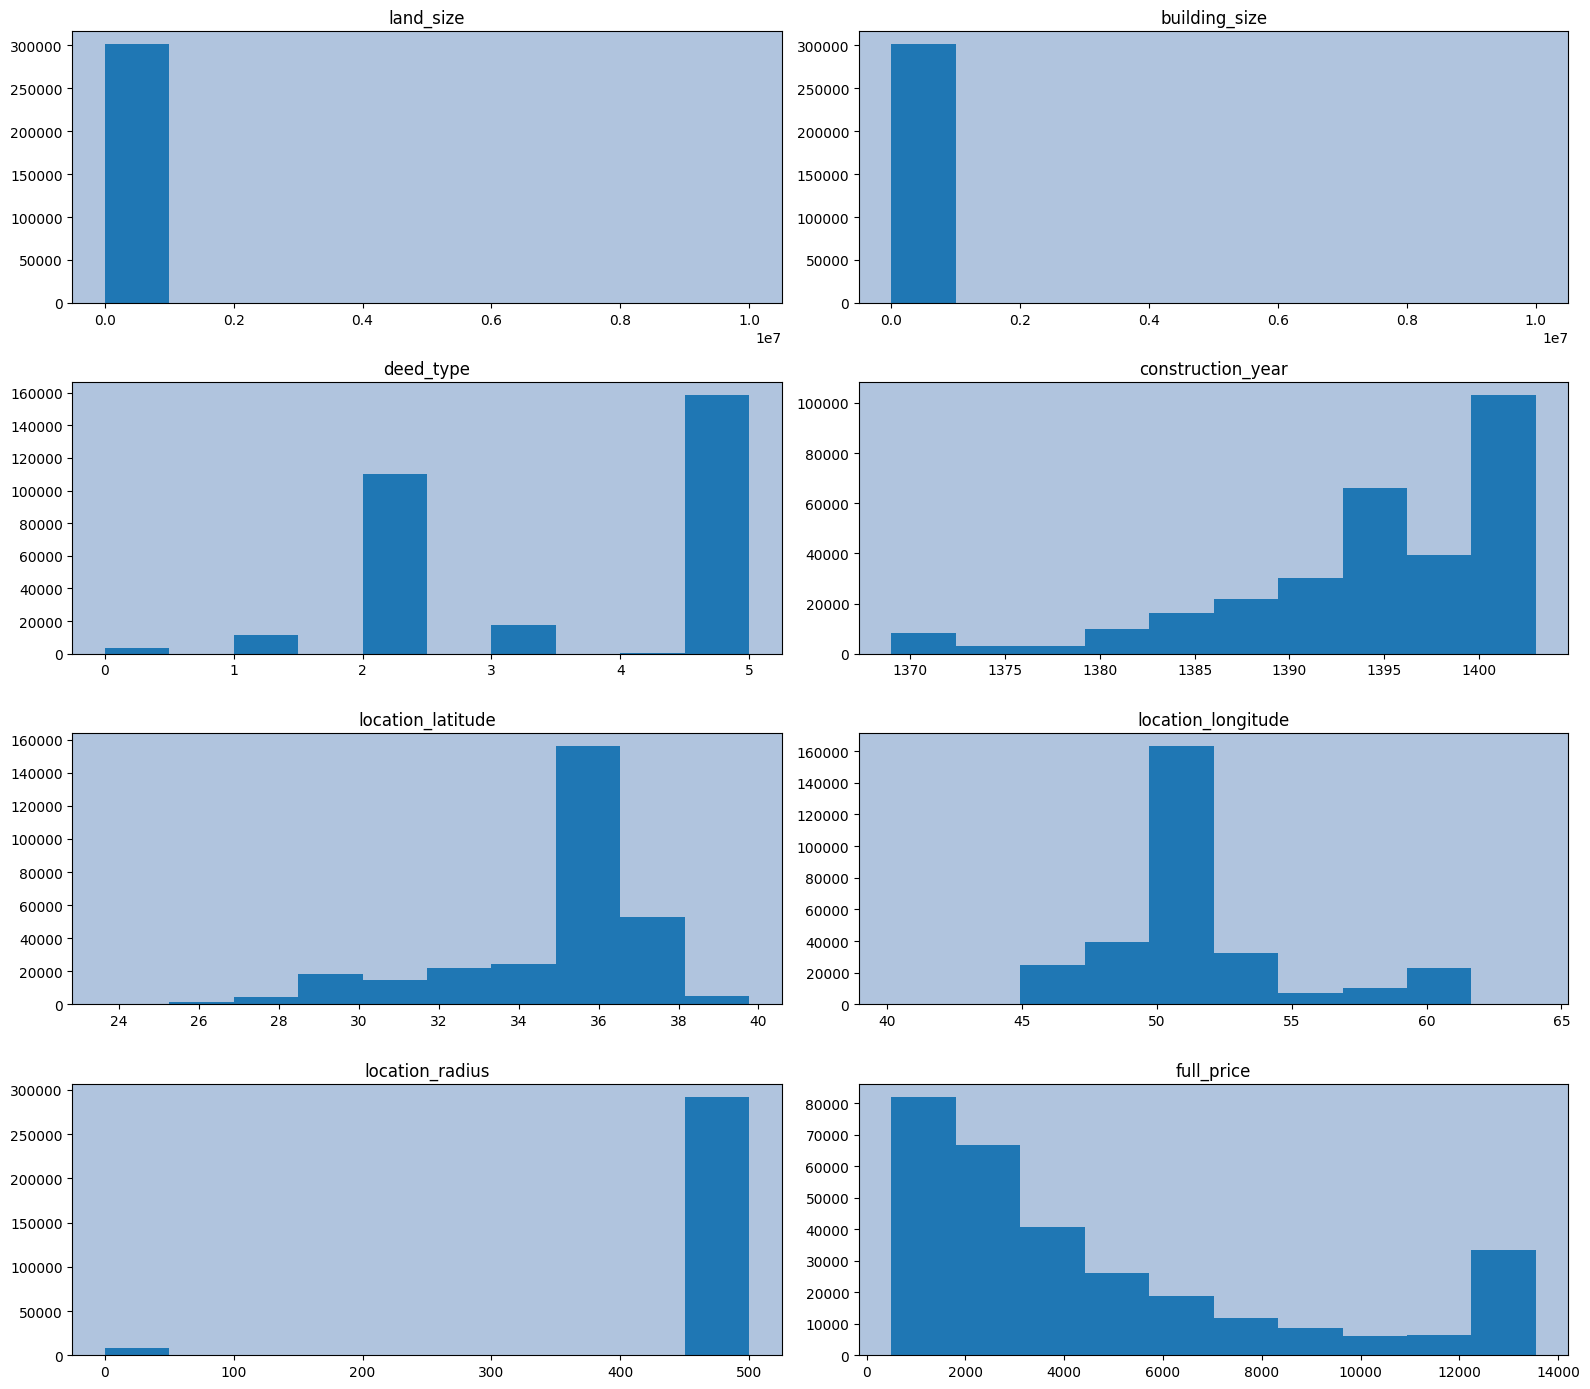

In [361]:
fig = plt.figure(figsize=(16, 14))
for i, c in enumerate(cols):
    ax = plt.subplot(4, 2, i+1)
    ax.set_facecolor('lightsteelblue')
    plt.hist(train_data[c])
    plt.title(c)
    plt.ylabel("")
    plt.tight_layout()
plt.show()

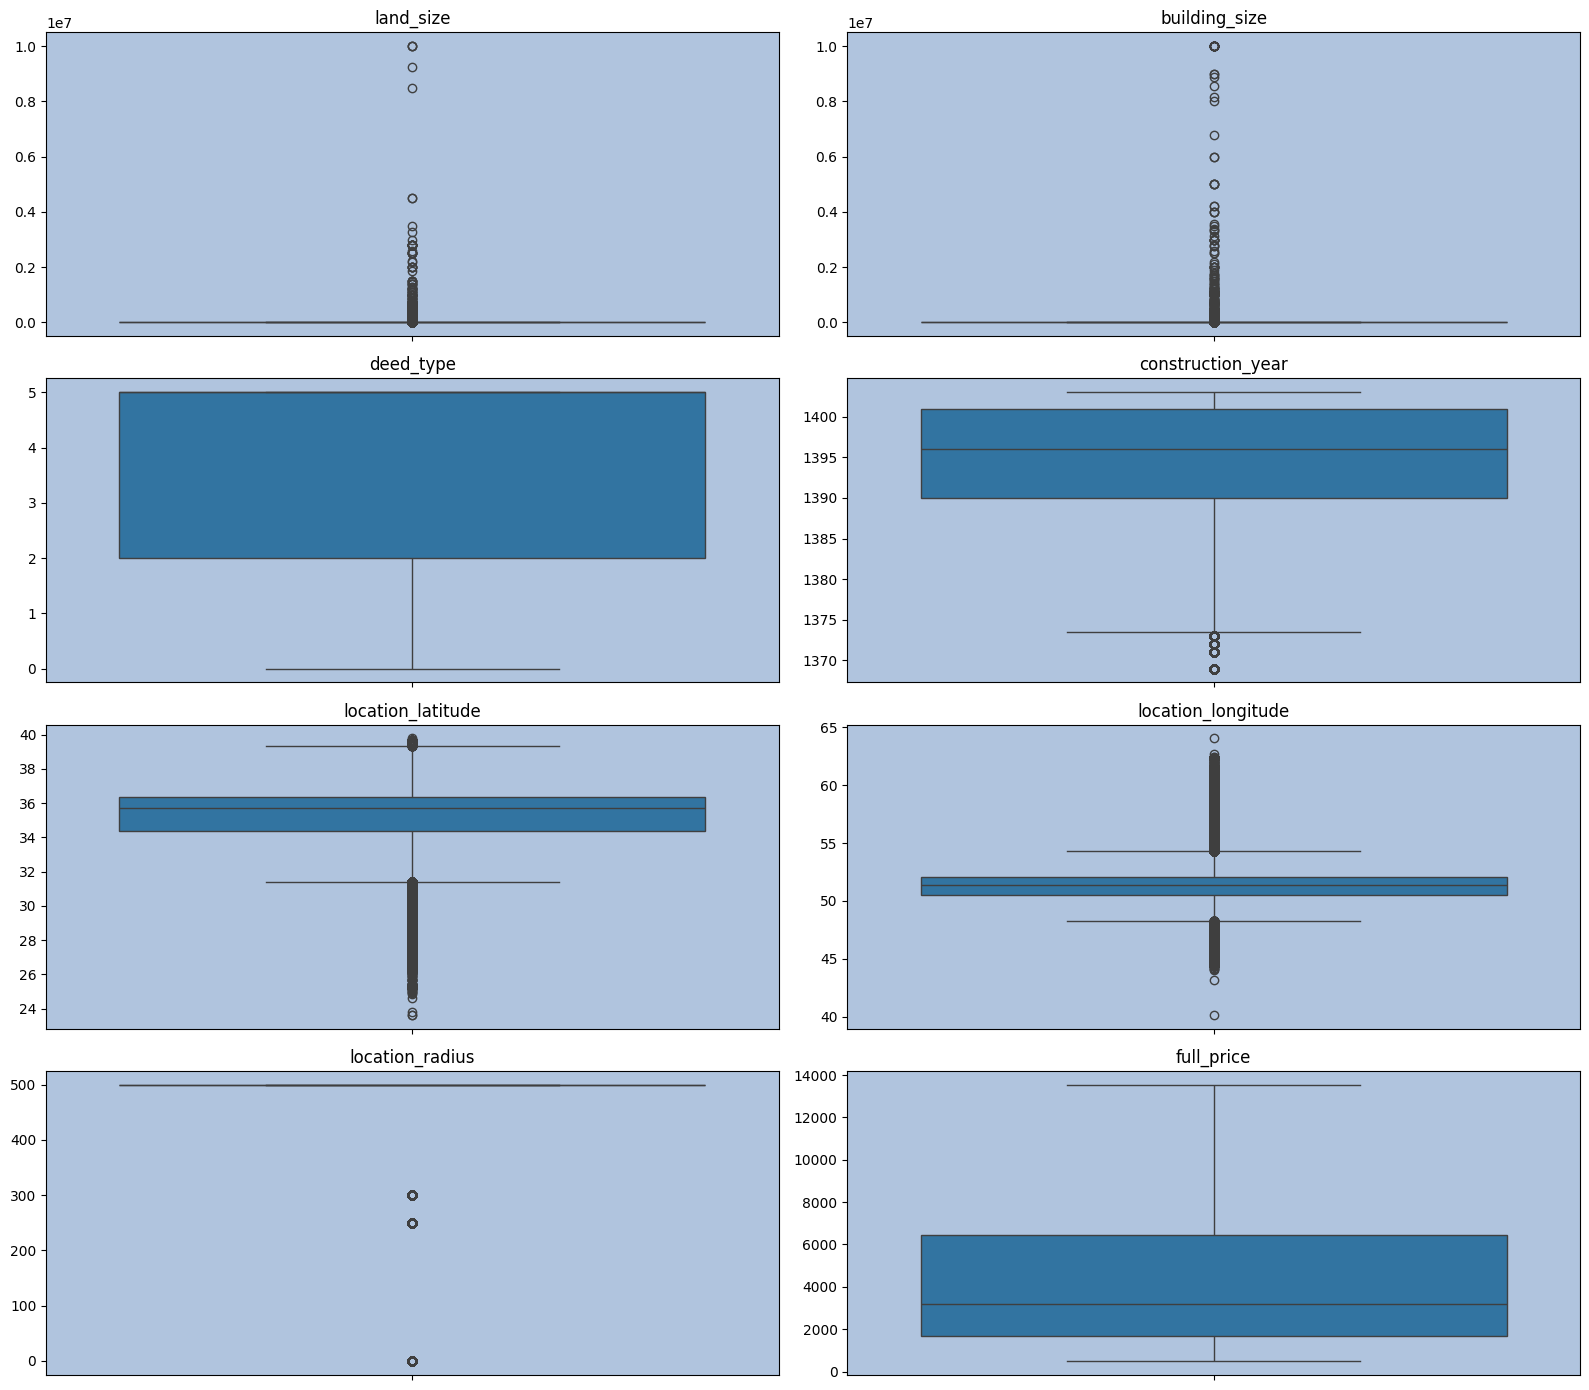

In [362]:
fig = plt.figure(figsize=(16, 14))
for i, c in enumerate(cols):
    ax = plt.subplot(4, 2, i+1)
    ax.set_facecolor('lightsteelblue')
    sns.boxplot(train_data[c])
    plt.title(c)
    plt.ylabel("")
    plt.tight_layout()
plt.show()

In [363]:
cols.remove('location_radius')
cols

['land_size',
 'building_size',
 'deed_type',
 'construction_year',
 'location_latitude',
 'location_longitude',
 'full_price']

In [364]:
def replace_by_condition(df, c, c_name, upper, lower):
    c = np.where(c>upper, upper, c)
    c = np.where(c<lower, lower, c)
    df.loc[:, c_name] = c
    return df

def replace_outliers_for_datasets(df, valid_df, test_df, c_name):
    c = df[c_name].astype(float)
    c_valid = valid_df[c_name].astype(float)
    c_test = test_df[c_name].astype(float)

    q1 = c.quantile(0.25)
    q3 = c.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5*iqr
    lower = q1 - 1.5*iqr
    
    df = replace_by_condition(df, c, c_name, upper, lower)
    valid_df = replace_by_condition(valid_df, c_valid, c_name, upper, lower)
    test_df = replace_by_condition(test_df, c_test, c_name, upper, lower)

    
    return df, valid_df, test_df

In [365]:
for c in cols:
    train_data, valid_data, test_data = replace_outliers_for_datasets(train_data, valid_data, test_data, c)

# Scaling

In [366]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301244 entries, 0 to 301243
Data columns (total 39 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   cat3_slug                  301244 non-null  int64  
 1   land_size                  301244 non-null  float64
 2   building_size              301244 non-null  float64
 3   deed_type                  301244 non-null  float64
 4   floor                      301244 non-null  int64  
 5   rooms_count                301244 non-null  int64  
 6   total_floors_count         301244 non-null  int64  
 7   unit_per_floor             301244 non-null  int64  
 8   has_balcony                301244 non-null  int64  
 9   has_elevator               301244 non-null  int64  
 10  has_warehouse              301244 non-null  int64  
 11  has_parking                301244 non-null  int64  
 12  construction_year          301244 non-null  float64
 13  is_rebuilt                 30

In [ ]:
sc = MinMaxScaler()
cols = train_data.columns

train_data1 = pd.DataFrame(sc.fit_transform(train_data), columns=cols)
valid_data1 = pd.DataFrame(sc.transform(valid_data[cols]), columns=cols)
test_data1 = pd.DataFrame(sc.transform(test_data[cols]), columns=cols)

# Check Corelation

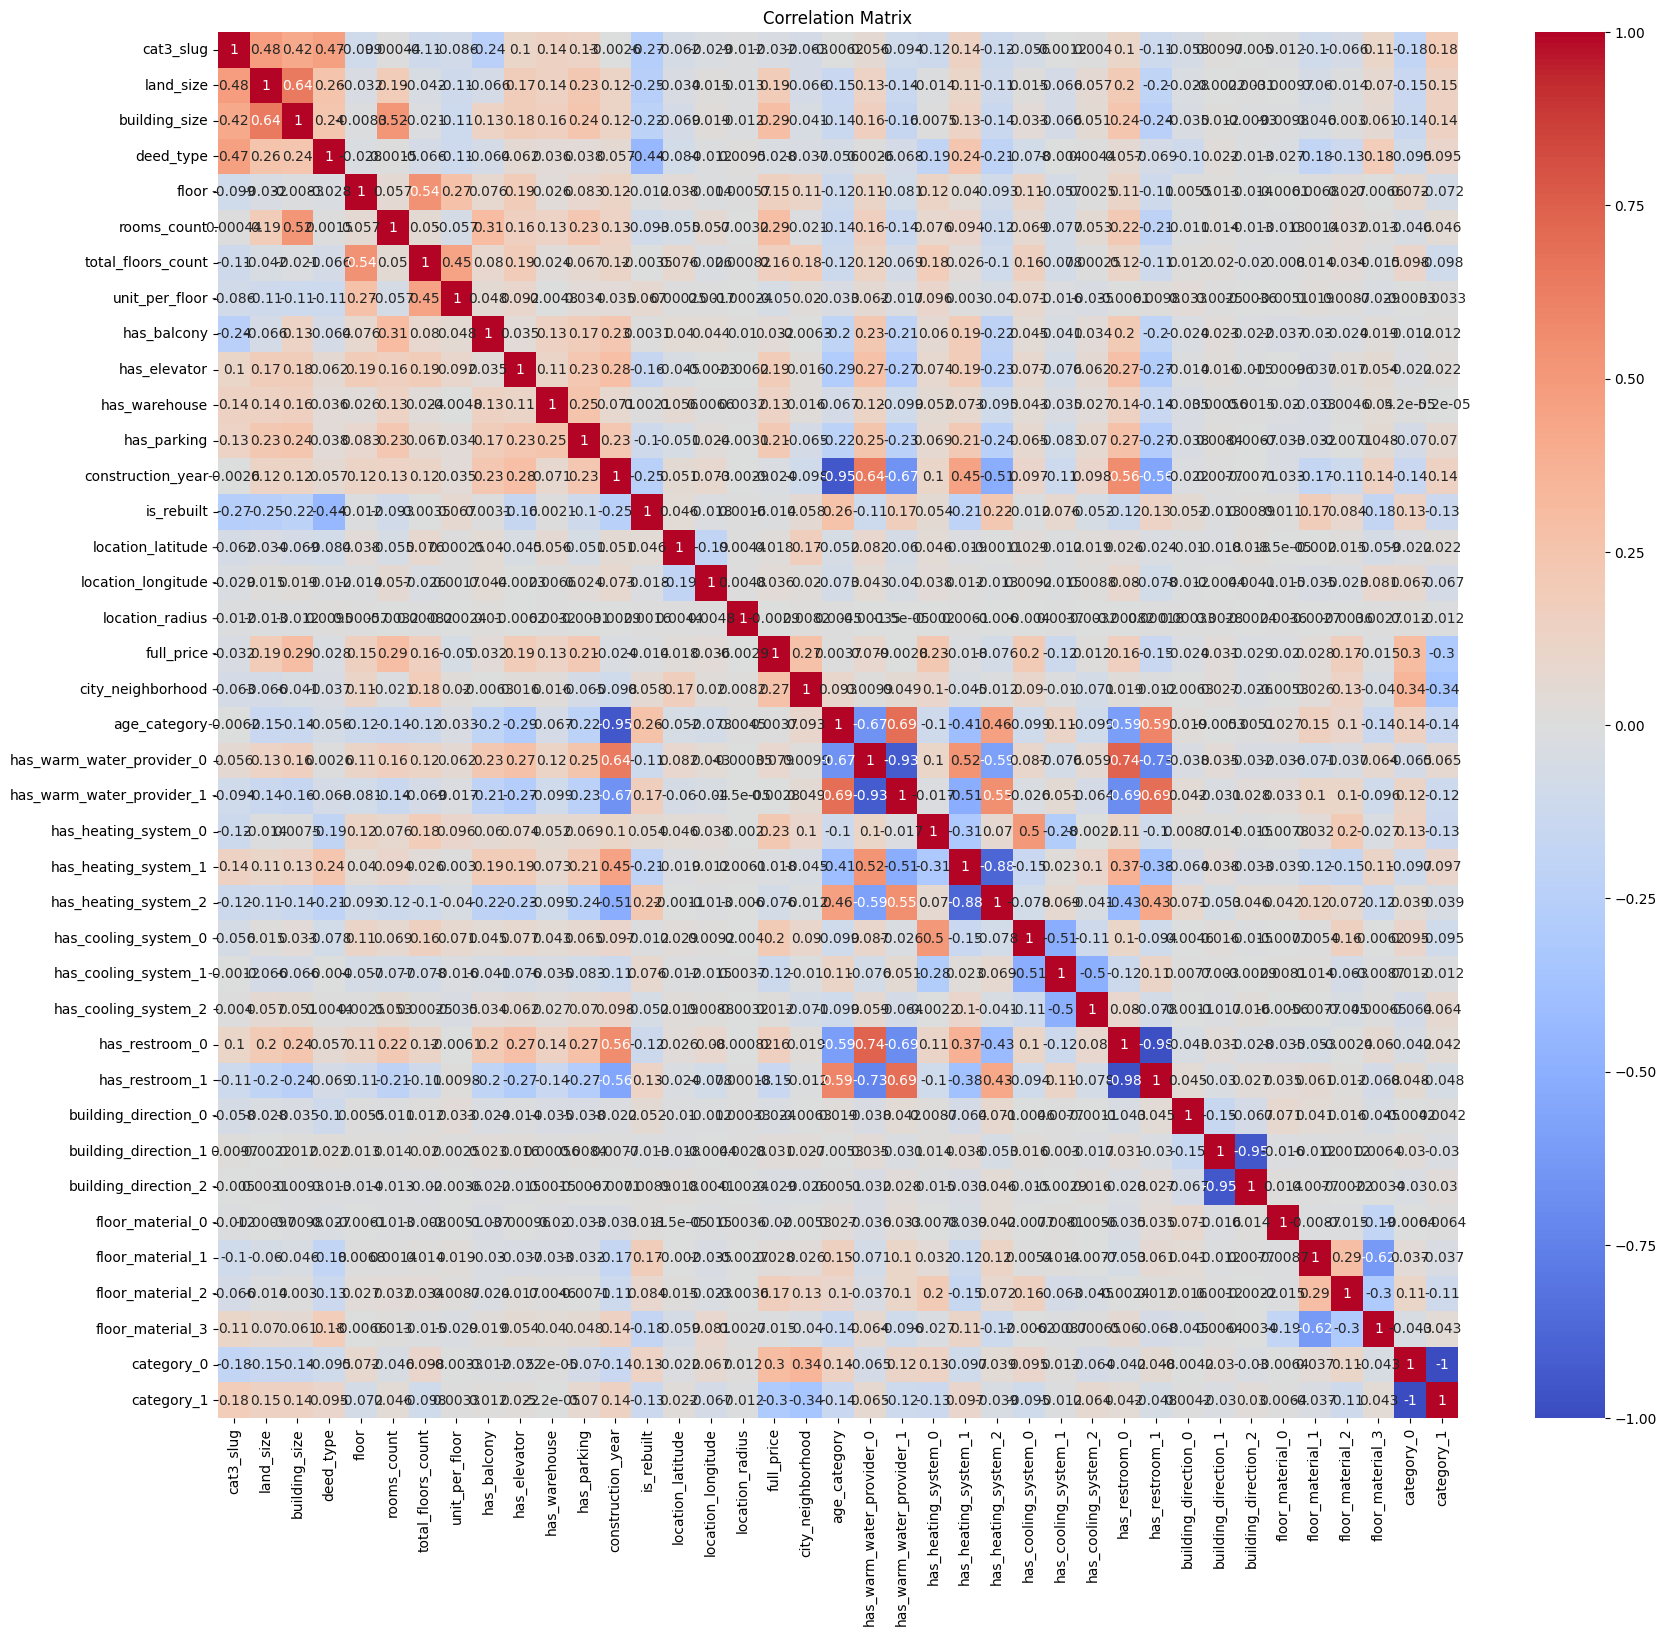

In [369]:
fig_cor , ax_cor = plt.subplots(1, 1, figsize=(20, 18))
sns.heatmap(train_data1.corr(numeric_only=True), annot=True, cmap='coolwarm')
ax_cor.set_title('Correlation Matrix')
plt.show()

In [370]:
train_data2 = train_data1.drop(['category_1', 'has_restroom_1', 'building_direction_2', 'construction_year'], axis=1)
valid_data2 = valid_data1.drop(['category_1', 'has_restroom_1', 'building_direction_2', 'construction_year'], axis=1)
test_data2 = test_data1.drop(['category_1', 'has_restroom_1', 'building_direction_2', 'construction_year'], axis=1)

In [371]:
train_data2

,cat3_slug,land_size,building_size,deed_type,floor,rooms_count,total_floors_count,unit_per_floor,has_balcony,has_elevator,...,has_cooling_system_1,has_cooling_system_2,has_restroom_0,building_direction_0,building_direction_1,floor_material_0,floor_material_1,floor_material_2,floor_material_3,category_0
0,0.000000,1.000000,1.000000,1.0,0.064516,1.0,0.035714,0.125,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.111111,0.233184,0.247557,0.6,0.096774,0.2,0.071429,0.125,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.000000,0.165919,0.208469,0.4,0.064516,0.4,0.035714,0.250,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.000000,0.446188,0.355049,1.0,0.322581,0.4,0.107143,0.125,1.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
4,0.111111,0.625561,0.908795,1.0,0.129032,0.8,0.142857,0.125,1.0,1.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301239,0.111111,0.446188,0.648208,0.4,0.129032,0.6,0.107143,0.125,1.0,1.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
301240,0.111111,0.334081,0.583062,0.4,0.096774,0.8,0.071429,0.125,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
301241,0.000000,0.221973,0.241042,0.4,0.096774,0.4,0.071429,0.375,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
301242,0.000000,0.179372,0.260586,1.0,0.064516,0.4,0.071429,0.125,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


In [372]:
train_data2.to_csv('E:/uni\AI quera\project\data_project1/final_train.csv')
valid_data2.to_csv('E:/uni\AI quera\project\data_project1/final_valid.csv')
test_data2.to_csv('E:/uni\AI quera\project\data_project1/final_test.csv')